In [2]:
import pandas as pd

df=pd.read_csv("ccm1.csv")
df2=pd.read_csv("beta1.csv")
df.info()

C:\Users\tonyd\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143763 entries, 0 to 143762
Data columns (total 72 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   gvkey     143763 non-null  int64  
 1   datadate  143763 non-null  object 
 2   fyear     143756 non-null  float64
 3   indfmt    143763 non-null  object 
 4   consol    143763 non-null  object 
 5   popsrc    143763 non-null  object 
 6   datafmt   143763 non-null  object 
 7   tic       143761 non-null  object 
 8   cusip     143763 non-null  object 
 9   conm      143763 non-null  object 
 10  curcd     143756 non-null  object 
 11  act       104072 non-null  float64
 12  at        130850 non-null  float64
 13  bkvlps    129825 non-null  float64
 14  capx      126915 non-null  float64
 15  che       130847 non-null  float64
 16  cogs      130755 non-null  float64
 17  dcs       37557 non-null   float64
 18  dcvsr     114987 non-null  float64
 19  dcvsub    114988 non-null  float64
 20  dcvt

In [2]:
import pandas as pd
import numpy as np

# Load the data
df_ccm = pd.read_csv("ccm1.csv")

# 1. PREPARATION: Convert datadate to datetime and sort for time-series calculations
df_ccm['datadate'] = pd.to_datetime(df_ccm['datadate'])
df_ccm = df_ccm.sort_values(by=['gvkey', 'datadate']).reset_index(drop=True)

# 2. CREATE LAGGED AND AVERAGE VARIABLES (Needed for ROA, ROE, Turnovers, Growth)

# Define variables for lagged and average calculations
lag_vars = ['at', 'seq', 'sale', 'ebit', 'invt', 'rect', 'xint']
for var in lag_vars:
    # Create lag (t-1) for each variable, grouped by company (gvkey)
    df_ccm[f'{var}_prev'] = df_ccm.groupby('gvkey')[var].shift(1)

# Calculate 2-period average for balance sheet items (required for ROA, ROE, Turnovers)
# We use the t-1 lag for the average calculation: (t + t-1) / 2
df_ccm['at_avg'] = (df_ccm['at'] + df_ccm['at_prev']) / 2
df_ccm['seq_avg'] = (df_ccm['seq'] + df_ccm['seq_prev']) / 2
df_ccm['invt_avg'] = (df_ccm['invt'] + df_ccm['invt_prev']) / 2
df_ccm['rect_avg'] = (df_ccm['rect'] + df_ccm['rect_prev']) / 2

# 3. CALCULATE NEW FINANCIAL RATIOS AND VARIABLES

# --- LEVERAGE, LIQUIDITY, AND SOLVENCY ---

# Financial Leverage = Total Liabilities / Total Assets
df_ccm['Financial_Leverage'] = df_ccm['lt'] / df_ccm['at']

# Current Ratio = Current Assets / Current Liabilities
df_ccm['Current_Ratio'] = df_ccm['act'] / df_ccm['lct']

# Quick Ratio = (Current Assets - Inventory) / Current Liabilities
df_ccm['Quick_Ratio'] = (df_ccm['act'] - df_ccm['invt']) / df_ccm['lct']

# Debt to Equity = (Long-Term Debt + Debt in Current Liabilities) / Shareholders' Equity
df_ccm['Debt_to_Equity'] = (df_ccm['dltt'] + df_ccm['dlc']) / df_ccm['seq']

# Interest Coverage = EBIT / Interest Expense
df_ccm['Interest_Coverage'] = df_ccm['ebit'] / df_ccm['xint']

# --- PROFITABILITY ---

# Net Margin = Net Income / Sales
df_ccm['Net_Margin'] = df_ccm['ni'] / df_ccm['sale']

# ROA = Net Income / Average Total Assets
df_ccm['ROA'] = df_ccm['ni'] / df_ccm['at_avg']

# ROE = Net Income / Average Shareholders' Equity
df_ccm['ROE'] = df_ccm['ni'] / df_ccm['seq_avg']

# --- GROWTH, INTENSITY, AND VOLATILITY ---

# Sales Growth = % Change in Net Sales (SALE)
df_ccm['Sales_Growth'] = (df_ccm['sale'] - df_ccm['sale_prev']) / df_ccm['sale_prev']

# R&D Intensity = R&D Expense / Sales
df_ccm['RD_Intensity'] = df_ccm['xrd'] / df_ccm['sale']

# Capex / Total Assets (Investment Rate)
df_ccm['Capex_to_AT'] = df_ccm['capx'] / df_ccm['at']

# Earnings Volatility = Std. Dev. of EBIT (Rolling 3 years)
# min_periods=3 requires at least 3 non-NaN values for the std dev calculation
df_ccm['EBIT_Vol_3Y'] = df_ccm.groupby('gvkey')['ebit'].rolling(
    window=3, min_periods=3
).std().reset_index(level=0, drop=True)

# Operating Leverage = % Change in EBIT / % Change in Revenue (SALE)
df_ccm['EBIT_Growth'] = (df_ccm['ebit'] - df_ccm['ebit_prev']) / df_ccm['ebit_prev']
df_ccm['Operating_Leverage'] = df_ccm['EBIT_Growth'] / df_ccm['Sales_Growth']

# --- VALUATION & ASSET EFFICIENCY ---

# Book to Market Ratio = Shareholders' Equity / Market Value
df_ccm['Book_to_Market'] = df_ccm['seq'] / df_ccm['mkvalt']

# Asset Turnover = Sales / Average Total Assets
df_ccm['Asset_Turnover'] = df_ccm['sale'] / df_ccm['at_avg']

# Inventory Turnover = COGS / Average Inventory
df_ccm['Inventory_Turnover'] = df_ccm['cogs'] / df_ccm['invt_avg']

# Receivables Turnover = Sales / Average Receivables
df_ccm['Receivables_Turnover'] = df_ccm['sale'] / df_ccm['rect_avg']

# Asset Composition (Intangibles/Total Assets)
df_ccm['Intan_to_AT'] = df_ccm['intan'] / df_ccm['at']

# --- FINAL CLEANUP ---

# Replace infinite values (from division by zero in ratios) with NaN
numeric_cols = df_ccm.select_dtypes(include=[np.number]).columns
df_ccm[numeric_cols] = df_ccm[numeric_cols].replace([np.inf, -np.inf], np.nan)

# Create the final updated_ccm DataFrame
# List of new columns to keep, plus the original ones
new_columns = [
    'Financial_Leverage', 'Current_Ratio', 'Quick_Ratio', 'Debt_to_Equity',
    'Interest_Coverage', 'Net_Margin', 'ROA', 'ROE', 'Sales_Growth',
    'RD_Intensity', 'Capex_to_AT', 'EBIT_Vol_3Y', 'Operating_Leverage',
    'Book_to_Market', 'Asset_Turnover', 'Inventory_Turnover',
    'Receivables_Turnover', 'Intan_to_AT'
]

# We need the original columns, but exclude the intermediate calculation columns
original_cols = [col for col in df_ccm.columns if col not in [
    'at_prev', 'seq_prev', 'sale_prev', 'ebit_prev', 'invt_prev', 'rect_prev',
    'xint_prev', 'at_avg', 'seq_avg', 'invt_avg', 'rect_avg', 'EBIT_Growth'
]]

# Final DataFrame includes all original columns and the new calculated columns
updated_ccm = df_ccm[original_cols + new_columns]

print(f"Created updated_ccm with {len(updated_ccm.columns)} columns.")

# Display the first few rows of the new columns along with identifiers
updated_ccm[['gvkey', 'datadate', 'at', 'mkvalt',
                   'Financial_Leverage', 'Quick_Ratio', 'Debt_to_Equity',
                   'ROA', 'Net_Margin', 'Sales_Growth', 'RD_Intensity',
                   'Asset_Turnover', 'Intan_to_AT']].head(5)

Created updated_ccm with 108 columns.


,gvkey,datadate,at,mkvalt,Financial_Leverage,Financial_Leverage,Quick_Ratio,Quick_Ratio,Debt_to_Equity,Debt_to_Equity,...,Net_Margin,Net_Margin,Sales_Growth,Sales_Growth,RD_Intensity,RD_Intensity,Asset_Turnover,Asset_Turnover,Intan_to_AT,Intan_to_AT
0,1004,2000-05-31,740.998,372.7519,0.541814,0.541814,1.069792,1.069792,0.608989,0.608989,...,0.034328,0.034328,NaN,NaN,NaN,NaN,NaN,NaN,0.052416,0.052416
1,1004,2001-05-31,701.854,377.1180,0.515267,0.515267,1.317995,1.317995,0.569172,0.569172,...,0.021196,0.021196,-0.146513,-0.146513,NaN,NaN,1.211843,1.211843,0.064650,0.064650
2,1004,2002-05-31,710.199,364.5928,0.563172,0.563172,0.997368,0.997368,0.838796,0.838796,...,-0.092277,-0.092277,-0.269411,-0.269411,NaN,NaN,0.904670,0.904670,0.070462,0.070462
3,1004,2003-05-31,686.621,143.3295,0.570377,0.570377,0.670308,0.670308,0.870930,0.870930,...,-0.020467,-0.020467,-0.050701,-0.050701,NaN,NaN,0.868168,0.868168,0.072710,0.072710
4,1004,2004-05-31,709.292,308.9071,0.574669,0.574669,1.409093,1.409093,0.835503,0.835503,...,0.005375,0.005375,0.075240,0.075240,NaN,NaN,0.934095,0.934095,0.067349,0.067349


Total firms-years: 25354
Train period: 2001 - 2019 (21093 observations)
Test period: 2020 - 2024 (4261 observations)
--------------------------------------------------
Training Random Forest...
Random Forest R²: -0.003315, RMSE: 0.3254
Training Scikit-learn Gradient Boosting Regressor...
Gradient Boosting R²: -0.003531, RMSE: 0.3254
Training Neural Network (MLP)...
Neural Network R²: -0.008583, RMSE: 0.3262
--------------------------------------------------


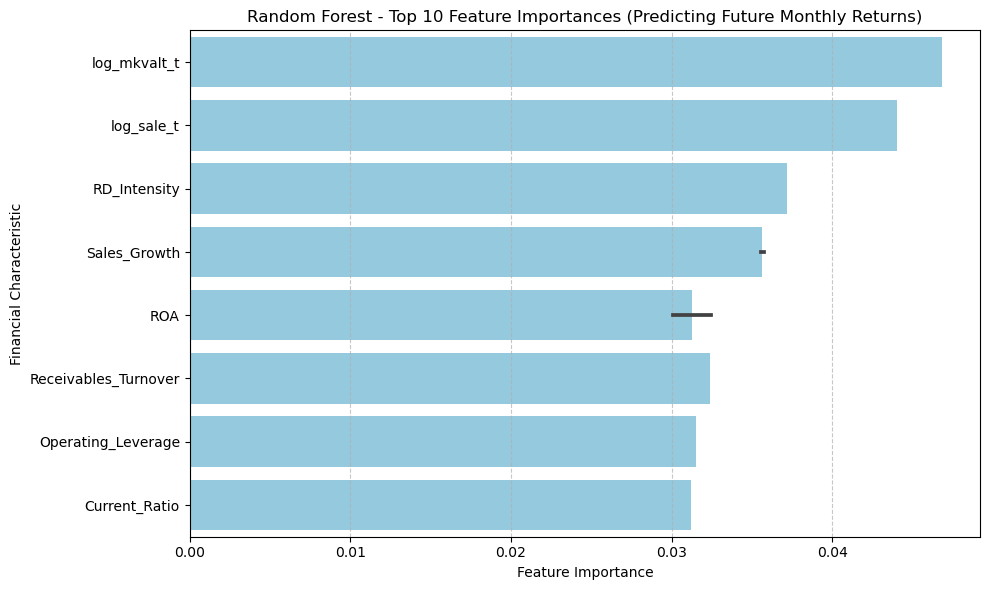

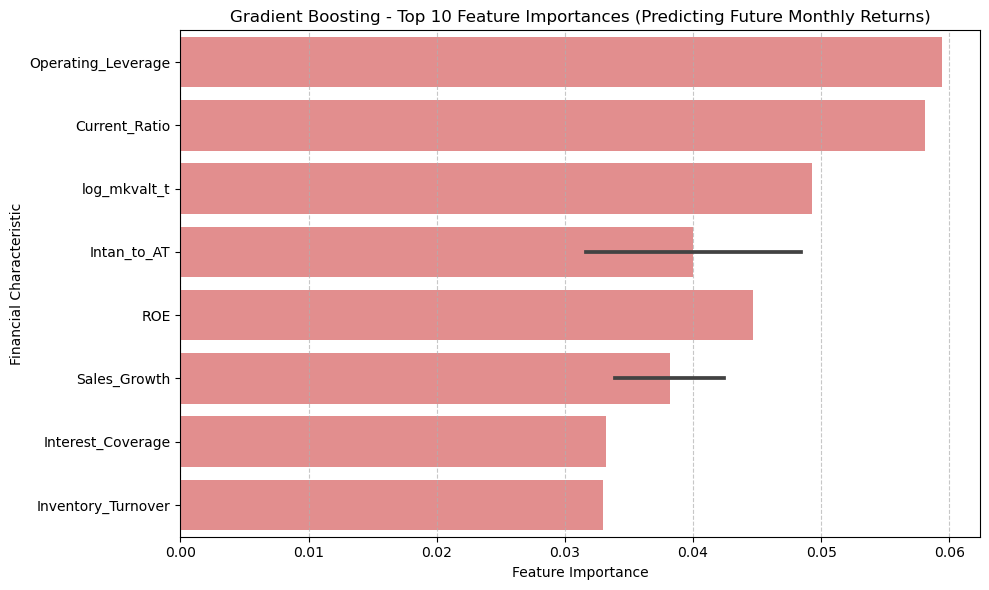


Model Performance Comparison (Out-of-Sample Test Set for Monthly Returns Prediction):
|                   | R2        | MSE      | RMSE     |
|:------------------|:----------|:---------|:---------|
| Random Forest     | -0.003315 | 0.105881 | 0.325393 |
| Gradient Boosting | -0.003531 | 0.105904 | 0.325428 |
| Neural Network    | -0.008583 | 0.106437 | 0.326246 |


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- START: RE-RUN DATA PREPARATION TO ENSURE 'updated_ccm' EXISTS ---

# Load the data (assuming ccm1.csv is in the directory)
df_ccm = pd.read_csv("ccm1.csv")

# 1. PREPARATION: Convert datadate to datetime and sort for time-series calculations
df_ccm['datadate'] = pd.to_datetime(df_ccm['datadate'])
df_ccm = df_ccm.sort_values(by=['gvkey', 'datadate']).reset_index(drop=True)

# 2. CREATE LAGGED AND AVERAGE VARIABLES

lag_vars = ['at', 'seq', 'sale', 'ebit', 'invt', 'rect', 'xint']
for var in lag_vars:
    df_ccm[f'{var}_prev'] = df_ccm.groupby('gvkey')[var].shift(1)

df_ccm['at_avg'] = (df_ccm['at'] + df_ccm['at_prev']) / 2
df_ccm['seq_avg'] = (df_ccm['seq'] + df_ccm['seq_prev']) / 2
df_ccm['invt_avg'] = (df_ccm['invt'] + df_ccm['invt_prev']) / 2
df_ccm['rect_avg'] = (df_ccm['rect'] + df_ccm['rect_prev']) / 2

# 3. CALCULATE NEW FINANCIAL RATIOS AND VARIABLES
df_ccm['Financial_Leverage'] = df_ccm['lt'] / df_ccm['at']
df_ccm['Current_Ratio'] = df_ccm['act'] / df_ccm['lct']
df_ccm['Quick_Ratio'] = (df_ccm['act'] - df_ccm['invt']) / df_ccm['lct']
df_ccm['Debt_to_Equity'] = (df_ccm['dltt'] + df_ccm['dlc']) / df_ccm['seq']
df_ccm['Interest_Coverage'] = df_ccm['ebit'] / df_ccm['xint']
df_ccm['Net_Margin'] = df_ccm['ni'] / df_ccm['sale']
df_ccm['ROA'] = df_ccm['ni'] / df_ccm['at_avg']
df_ccm['ROE'] = df_ccm['ni'] / df_ccm['seq_avg']

df_ccm['Sales_Growth'] = (df_ccm['sale'] - df_ccm['sale_prev']) / df_ccm['sale_prev']
df_ccm['RD_Intensity'] = df_ccm['xrd'] / df_ccm['sale']
df_ccm['Capex_to_AT'] = df_ccm['capx'] / df_ccm['at']
df_ccm['EBIT_Vol_3Y'] = df_ccm.groupby('gvkey')['ebit'].rolling(
    window=3, min_periods=3
).std().reset_index(level=0, drop=True)
df_ccm['EBIT_Growth'] = (df_ccm['ebit'] - df_ccm['ebit_prev']) / df_ccm['ebit_prev']
df_ccm['Operating_Leverage'] = df_ccm['EBIT_Growth'] / df_ccm['Sales_Growth']

df_ccm['Book_to_Market'] = df_ccm['seq'] / df_ccm['mkvalt']
df_ccm['Asset_Turnover'] = df_ccm['sale'] / df_ccm['at_avg']
df_ccm['Inventory_Turnover'] = df_ccm['cogs'] / df_ccm['invt_avg']
df_ccm['Receivables_Turnover'] = df_ccm['sale'] / df_ccm['rect_avg']
df_ccm['Intan_to_AT'] = df_ccm['intan'] / df_ccm['at']

numeric_cols = df_ccm.select_dtypes(include=[np.number]).columns
df_ccm[numeric_cols] = df_ccm[numeric_cols].replace([np.inf, -np.inf], np.nan)

# Create the final updated_ccm DataFrame (excluding intermediate lag/avg columns)
new_columns = [
    'Financial_Leverage', 'Current_Ratio', 'Quick_Ratio', 'Debt_to_Equity',
    'Interest_Coverage', 'Net_Margin', 'ROA', 'ROE', 'Sales_Growth',
    'RD_Intensity', 'Capex_to_AT', 'EBIT_Vol_3Y', 'Operating_Leverage',
    'Book_to_Market', 'Asset_Turnover', 'Inventory_Turnover',
    'Receivables_Turnover', 'Intan_to_AT'
]
intermediate_cols = [
    'at_prev', 'seq_prev', 'sale_prev', 'ebit_prev', 'invt_prev', 'rect_prev',
    'xint_prev', 'at_avg', 'seq_avg', 'invt_avg', 'rect_avg', 'EBIT_Growth'
]
original_cols = [col for col in df_ccm.columns if col not in intermediate_cols]
updated_ccm = df_ccm[original_cols + new_columns]

# --- END: RE-RUN DATA PREPARATION ---


# --- 1. DATA PREPARATION FOR ML (Monthly Returns) ---

# Ensure the DataFrame is sorted by gvkey and datadate
updated_ccm = updated_ccm.sort_values(by=['gvkey', 'datadate']).reset_index(drop=True)

# 🎯 NEW TARGET VARIABLE (Y): Next Month's Return (MthRet at t+1)
# NOTE: MthRet is assumed to be available in the ccm1.csv data
updated_ccm['MthRet_t1'] = updated_ccm.groupby('gvkey')['MthRet'].shift(-1)

# Prepare Predictor Variables (X): Characteristics at time t
characteristic_predictors = [
    'Financial_Leverage', 'Current_Ratio', 'Quick_Ratio', 'Debt_to_Equity',
    'Interest_Coverage', 'Net_Margin', 'ROA', 'ROE', 'Sales_Growth',
    'RD_Intensity', 'Capex_to_AT', 'EBIT_Vol_3Y', 'Operating_Leverage',
    'Book_to_Market', 'Asset_Turnover', 'Inventory_Turnover',
    'Receivables_Turnover', 'Intan_to_AT'
]

# Transform core variables to log for normalization (same as previous tasks)
log_cols = ['at', 'sale', 'ebit', 'xint', 'ni', 'seq', 'mkvalt']
for col in log_cols:
    updated_ccm[f'log_{col}_t'] = np.log(updated_ccm[col].abs().replace(0, np.nan))

# Update the list of predictors with the new log variables
log_predictors = [f'log_{col}_t' for col in log_cols]
FINAL_PREDICTORS = log_predictors + characteristic_predictors

# Clean Data: Drop rows with NaN in the target or any predictor
# 🎯 CHANGE: Target column is now 'MthRet_t1'
ml_df = updated_ccm[['gvkey', 'datadate', 'MthRet_t1'] + FINAL_PREDICTORS].dropna()

X = ml_df[FINAL_PREDICTORS]
# 🎯 CHANGE: Target is now 'MthRet_t1'
Y = ml_df['MthRet_t1']

# --- 2. TIME-SERIES TRAIN-TEST SPLIT (Re-using 80/20 yearly split) ---

# Use fiscal year (fyear) as the time dimension for the split
ml_df['fyear'] = ml_df['datadate'].dt.year

# Determine the split year (80% for training, 20% for testing)
all_years = sorted(ml_df['fyear'].unique())
split_index = int(0.8 * len(all_years))
train_years = all_years[:split_index]
test_years = all_years[split_index:]

# Split the data
X_train, X_test = X[ml_df['fyear'].isin(train_years)], X[ml_df['fyear'].isin(test_years)]
Y_train, Y_test = Y[ml_df['fyear'].isin(train_years)], Y[ml_df['fyear'].isin(test_years)]

# Scale the data for the Neural Network
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Total firms-years: {len(ml_df)}")
print(f"Train period: {train_years[0]} - {train_years[-1]} ({len(X_train)} observations)")
print(f"Test period: {test_years[0]} - {test_years[-1]} ({len(X_test)} observations)")
print("-" * 50)

# --- 3. MACHINE LEARNING MODEL TRAINING AND EVALUATION ---

results_returns = {}

# 🎯 CHANGE: Update function to use the new results dictionary
def evaluate_model_returns(y_true, y_pred, model_name):
    """Calculates and stores R2, MSE, and RMSE."""
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    results_returns[model_name] = {'R2': r2, 'MSE': mse, 'RMSE': rmse}
    print(f"{model_name} R²: {r2:.6f}, RMSE: {rmse:.4f}") # Using more precision for R²

# --- A. Random Forest Regressor ---
print("Training Random Forest...")
rf_model_ret = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model_ret.fit(X_train, Y_train)
rf_pred_ret = rf_model_ret.predict(X_test)
evaluate_model_returns(Y_test, rf_pred_ret, 'Random Forest')

# --- B. Gradient Boosting Regressor (Scikit-learn) ---
print("Training Scikit-learn Gradient Boosting Regressor...")
gbr_model_ret = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
gbr_model_ret.fit(X_train, Y_train)
gbr_pred_ret = gbr_model_ret.predict(X_test)
evaluate_model_returns(Y_test, gbr_pred_ret, 'Gradient Boosting')

# --- C. Neural Network (MLP Regressor) ---
print("Training Neural Network (MLP)...")
nn_model_ret = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    max_iter=300,
    solver='adam',
    random_state=42
)
nn_model_ret.fit(X_train_scaled, Y_train)
nn_pred_ret = nn_model_ret.predict(X_test_scaled)
evaluate_model_returns(Y_test, nn_pred_ret, 'Neural Network')
print("-" * 50)

# --- 4. VISUALIZATION AND INTERPRETATION ---

# 4.1. Feature Importance (Random Forest)
rf_importance_ret = pd.Series(rf_model_ret.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=rf_importance_ret.values, y=rf_importance_ret.index, color='skyblue')
# 🎯 CHANGE: Title reflects the new target
plt.title('Random Forest - Top 10 Feature Importances (Predicting Future Monthly Returns)')
plt.xlabel('Feature Importance')
plt.ylabel('Financial Characteristic')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 4.2. Feature Importance (Gradient Boosting)
gbr_importance_ret = pd.Series(gbr_model_ret.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=gbr_importance_ret.values, y=gbr_importance_ret.index, color='lightcoral')
# 🎯 CHANGE: Title reflects the new target
plt.title('Gradient Boosting - Top 10 Feature Importances (Predicting Future Monthly Returns)')
plt.xlabel('Feature Importance')
plt.ylabel('Financial Characteristic')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 4.3. Comparison of Model Performance
performance_df_ret = pd.DataFrame(results_returns).T
print("\nModel Performance Comparison (Out-of-Sample Test Set for Monthly Returns Prediction):")
# 🎯 CHANGE: Use higher precision for R2 in the table
print(performance_df_ret.to_markdown(numalign="left", stralign="left", floatfmt=".6f"))

--- 1. Diagnosing Target Variable: Monthly Returns (Y_train) ---
count    21093.000000
mean         0.014513
std          0.145430
min         -0.861818
25%         -0.050360
50%          0.008443
75%          0.069971
max          2.808617
Name: MthRet_t1, dtype: float64


C:\Users\tonyd\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


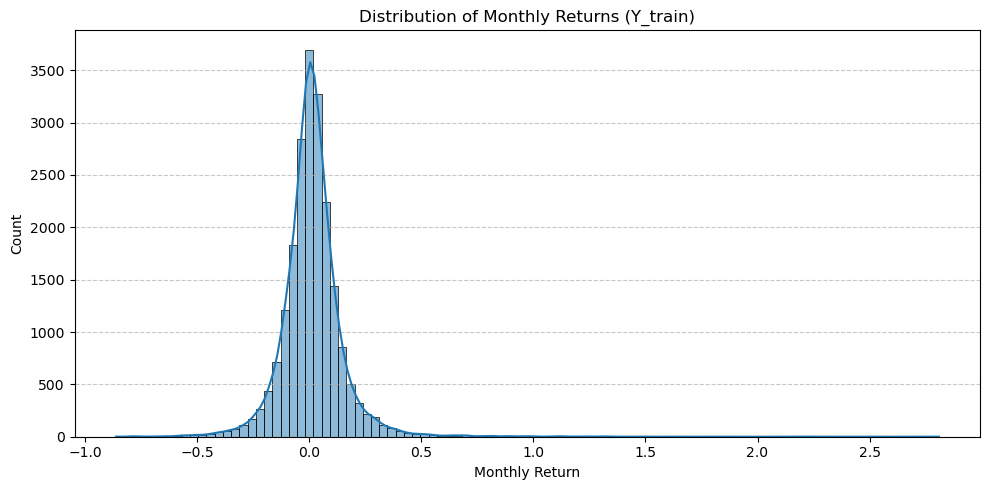


--- 2. Diagnosing Predictors: Financial Characteristics (X_train) ---
|                      |        min |   25% |   50% |   75% |       max |   mean |     std |
|:---------------------|-----------:|------:|------:|------:|----------:|-------:|--------:|
| log_at_t             |      -0.34 |  4.89 |  6.48 |  7.96 |     13.22 |   6.46 |    2.14 |
| log_sale_t           |      -6.91 |  4.76 |  6.45 |  7.88 |     13.15 |   6.33 |    2.25 |
| log_ebit_t           |      -6.91 |  2.33 |  3.98 |  5.58 |     11.17 |   3.96 |    2.32 |
| log_xint_t           |      -6.91 | -0.47 |  1.78 |  3.71 |      9.06 |   1.54 |    2.83 |
| log_ni_t             |      -6.21 |  2.22 |  3.68 |  5.15 |     11.56 |   3.69 |    2.22 |
| log_seq_t            |      -6.91 |  4.19 |  5.69 |  7.01 |     12.21 |   5.61 |    2.08 |
| log_mkvalt_t         |      -0.97 |  4.89 |  6.53 |  8.04 |     13.84 |   6.50 |    2.26 |
| Financial_Leverage   |       0.02 |  0.34 |  0.50 |  0.66 |      6.86 |   0.53 |    0.30 |

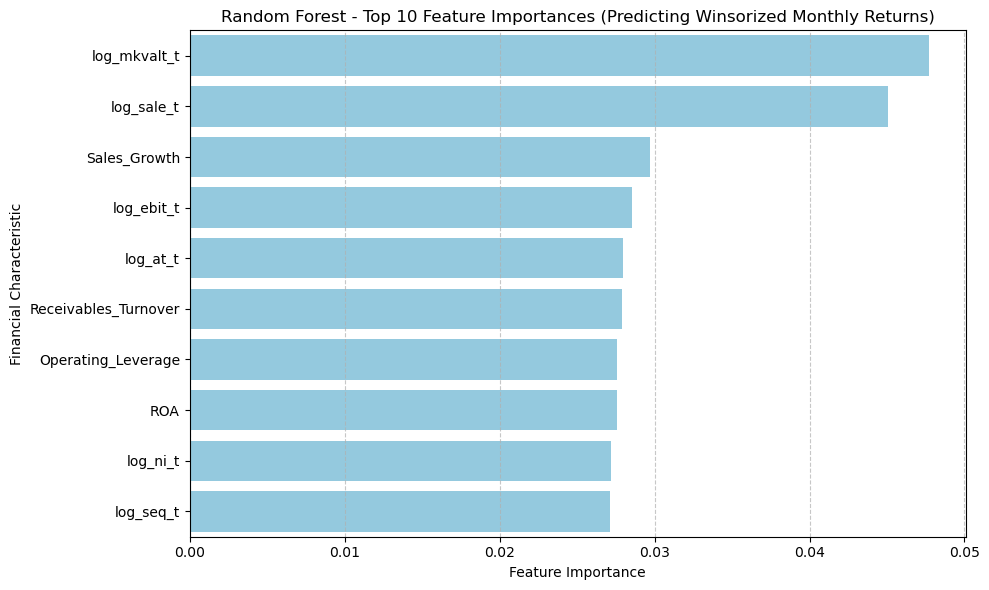

In [6]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

# --- Assume 'X_train', 'Y_train', 'X_test', 'Y_test' are in memory ---
# If not, you must re-run the previous data preparation steps first.

# --- TEST 1: Check Distribution of the Target Variable (MthRet_t1) ---
print("--- 1. Diagnosing Target Variable: Monthly Returns (Y_train) ---")
print(Y_train.describe())

plt.figure(figsize=(10, 5))
sns.histplot(Y_train, bins=100, kde=True)
plt.title('Distribution of Monthly Returns (Y_train)')
plt.xlabel('Monthly Return')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show() # 

# --- TEST 2: Check Distribution of Predictors (X_train) ---
print("\n--- 2. Diagnosing Predictors: Financial Characteristics (X_train) ---")
# Display summary stats to look for extreme outliers (e.g., huge min/max)
predictor_stats = X_train.describe().T
print(predictor_stats[['min', '25%', '50%', '75%', 'max', 'mean', 'std']].to_markdown(floatfmt=".2f"))


# --- 3. THE FIX: Winsorize Outliers using DataFrame-level .clip() ---

print("\nApplying Winsorization (1% and 99% quantiles)...")

# --- THIS IS THE FIX ---
# 1. Calculate all lower and upper quantiles from the TRAINING data
lower_limits = X_train.quantile(0.01)
upper_limits = X_train.quantile(0.99)

# 2. Apply these limits to both training and testing DataFrames.
#    The 'axis=1' argument tells clip to align the Series (limits) by columns.
X_train_winsorized = X_train.clip(lower=lower_limits, upper=upper_limits, axis=1)
X_test_winsorized = X_test.clip(lower=lower_limits, upper=upper_limits, axis=1)

# 3. Winsorize the target variable (Y) as well.
y_lower_limit = Y_train.quantile(0.01)
y_upper_limit = Y_train.quantile(0.99)
Y_train_winsorized = Y_train.clip(lower=y_lower_limit, upper=y_upper_limit)
Y_test_winsorized = Y_test.clip(lower=y_lower_limit, upper=y_upper_limit) # Use same training limits
# --- END OF FIX ---

print("Winsorization complete.")

print(f"\n--- 4. Re-Training Random Forest on Winsorized Data ---")

# Re-train only the Random Forest model to see if performance improves
rf_model_winsorized = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model_winsorized.fit(X_train_winsorized, Y_train_winsorized)
rf_pred_winsorized = rf_model_winsorized.predict(X_test_winsorized)

# Evaluate the new model using the winsorized test target
r2_winsorized = r2_score(Y_test_winsorized, rf_pred_winsorized)
rmse_winsorized = np.sqrt(mean_squared_error(Y_test_winsorized, rf_pred_winsorized))

# Using the R-squared from your previous output for comparison
print(f"Original Random Forest R²:   {-0.003315:.6f}") 
print(f"Winsorized Random Forest R²: {r2_winsorized:.6f}, RMSE: {rmse_winsorized:.4f}")

if r2_winsorized > 0:
    print("\nSUCCESS: Winsorizing produced a positive R².")
else:
    print("\nNOTE: R² is still negative or zero. This confirms the extreme difficulty of predicting monthly returns.")

# 4.1. Feature Importance (Random Forest - Winsorized)
rf_importance_ret = pd.Series(rf_model_winsorized.feature_importances_, index=X_train_winsorized.columns).sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=rf_importance_ret.values, y=rf_importance_ret.index, color='skyblue')
plt.title('Random Forest - Top 10 Feature Importances (Predicting Winsorized Monthly Returns)')
plt.xlabel('Feature Importance')
plt.ylabel('Financial Characteristic')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show() #

--- Loading Loughran-McDonald Sentiment Data ---
Sentiment Data loaded successfully.
Normalizing sentiment features by N_Words...
Sentiment data normalized and prepared for merge.

--- Loading ccm1.csv and creating 'updated_ccm' ---
'updated_ccm' DataFrame created successfully.


C:\Users\tonyd\AppData\Local\Temp\ipykernel_33516\3570519604.py:140: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merged_df[col].fillna(0, inplace=True)



Sentiment data merged successfully.

Using 34 total predictors (Financials + Sentiment).

Total firms-years for ML: 25354
Train period: 2001 - 2019 (21093 observations)
Test period: 2020 - 2024 (4261 observations)
--------------------------------------------------
Training Random Forest...
Random Forest (w/ Sentiment) R²: -0.003365, RMSE: 0.3254
Training Gradient Boosting...
Gradient Boosting (w/ Sentiment) R²: 0.003088, RMSE: 0.3244
Training Neural Network (MLP)...
Neural Network (w/ Sentiment) R²: -0.053652, RMSE: 0.3335
--------------------------------------------------


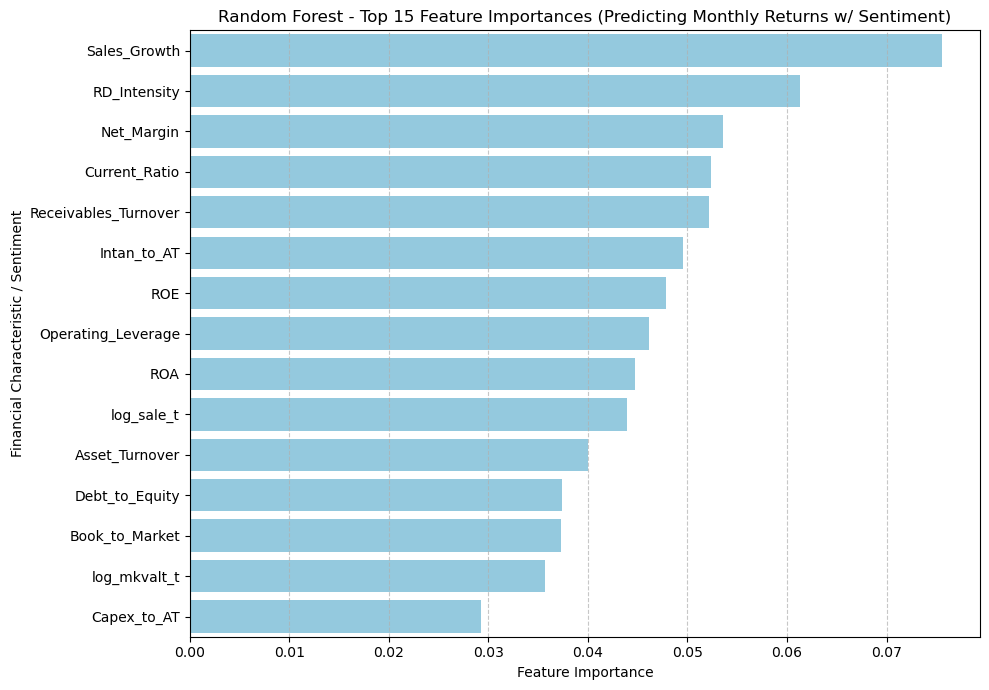

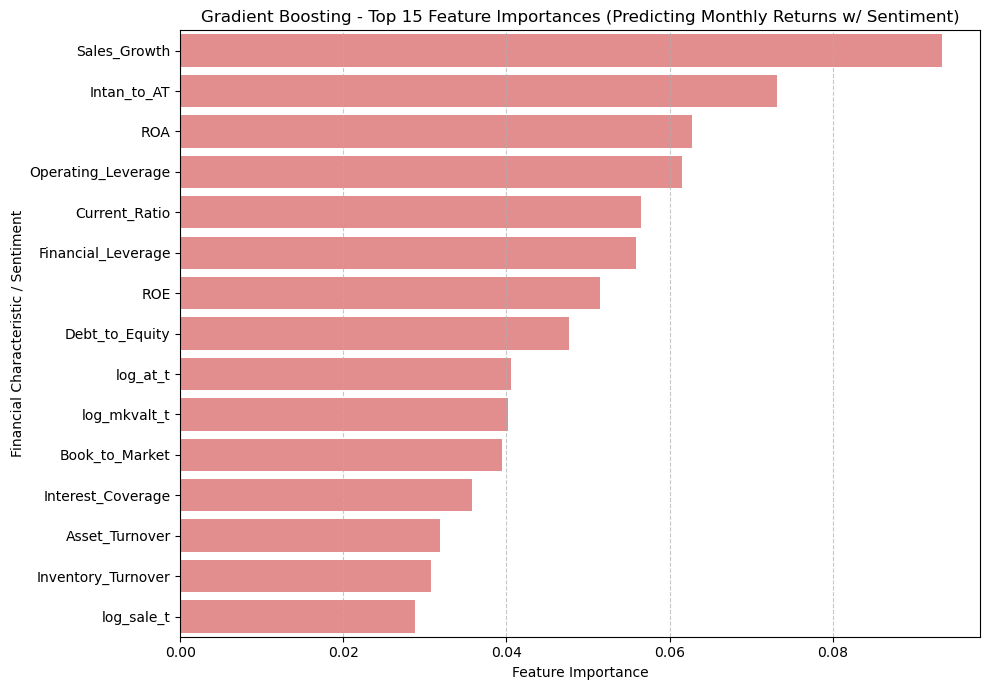


Model Performance Comparison (Out-of-Sample Test Set for Monthly Returns Prediction w/ Sentiment):
|                                  | R2        | MSE      | RMSE     |
|:---------------------------------|:----------|:---------|:---------|
| Random Forest (w/ Sentiment)     | -0.003365 | 0.105886 | 0.325401 |
| Gradient Boosting (w/ Sentiment) | 0.003088  | 0.105205 | 0.324353 |
| Neural Network (w/ Sentiment)    | -0.053652 | 0.111193 | 0.333456 |


In [6]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Load and Prepare Sentiment Data (Using Correct Column Names) ---
print("--- Loading Loughran-McDonald Sentiment Data ---")
try:
    df_sentiment = pd.read_csv("Loughran-McDonald_10X_Summaries_1993-2024.csv")
    print("Sentiment Data loaded successfully.")

    # Convert FILING_DATE to datetime
    df_sentiment['FILING_DATE'] = pd.to_datetime(df_sentiment['FILING_DATE'], format='%Y%m%d')
    # Ensure filing_year is present
    if 'filing_year' not in df_sentiment.columns:
        df_sentiment['filing_year'] = df_sentiment['FILING_DATE'].dt.year

    # Define the actual sentiment columns from your file
    sentiment_cols_actual = [
        'N_Negative', 'N_Positive', 'N_Uncertainty', 'N_Litigious',
        'N_StrongModal', 'N_WeakModal', 'N_Constraining', 'N_Complexity', 'N_Negation'
    ]
    norm_col = 'N_Words'
    new_norm_cols = []

    print("Normalizing sentiment features by N_Words...")
    for col in sentiment_cols_actual:
        new_col_name = f"{col.replace('N_', 'LM_')}_Norm"
        df_sentiment[new_col_name] = np.where(
            (df_sentiment[norm_col].isna()) | (df_sentiment[norm_col] == 0),
            0,
            df_sentiment[col] / df_sentiment[norm_col]
        )
        new_norm_cols.append(new_col_name)

    # Select columns needed for merging
    df_sentiment_select = df_sentiment[['CIK', 'filing_year'] + new_norm_cols].copy()

    # Handle multiple filings per year: Keep the latest one
    df_sentiment_final = df_sentiment_select.sort_values(by=['CIK', 'filing_year']).drop_duplicates(subset=['CIK', 'filing_year'], keep='last')
    print("Sentiment data normalized and prepared for merge.")

except FileNotFoundError:
    print("ERROR: 'Loughran-McDonald_10X_Summaries_1993-2024.csv' not found. Cannot proceed.")
    raise SystemExit("Sentiment file not found.")
except Exception as e:
    print(f"An error occurred loading/processing the sentiment file: {e}")
    raise SystemExit("Error processing sentiment file.")


# --- 2. Load and Re-create 'updated_ccm' (with TYPOS FIXED) ---
print("\n--- Loading ccm1.csv and creating 'updated_ccm' ---")
try:
    df_ccm = pd.read_csv("ccm1.csv")

    # PREPARATION
    df_ccm['datadate'] = pd.to_datetime(df_ccm['datadate'])
    df_ccm = df_ccm.sort_values(by=['gvkey', 'datadate']).reset_index(drop=True)

    # LAGGED AND AVERAGE VARS
    lag_vars = ['at', 'seq', 'sale', 'ebit', 'invt', 'rect', 'xint']
    for var in lag_vars:
        df_ccm[f'{var}_prev'] = df_ccm.groupby('gvkey')[var].shift(1)
    df_ccm['at_avg'] = (df_ccm['at'] + df_ccm['at_prev']) / 2
    df_ccm['seq_avg'] = (df_ccm['seq'] + df_ccm['seq_prev']) / 2
    df_ccm['invt_avg'] = (df_ccm['invt'] + df_ccm['invt_prev']) / 2
    df_ccm['rect_avg'] = (df_ccm['rect'] + df_ccm['rect_prev']) / 2

    # CALCULATE RATIOS
    df_ccm['Financial_Leverage'] = df_ccm['lt'] / df_ccm['at']
    df_ccm['Current_Ratio'] = df_ccm['act'] / df_ccm['lct']
    df_ccm['Quick_Ratio'] = (df_ccm['act'] - df_ccm['invt']) / df_ccm['lct']
    df_ccm['Debt_to_Equity'] = (df_ccm['dltt'] + df_ccm['dlc']) / df_ccm['seq']
    df_ccm['Interest_Coverage'] = df_ccm['ebit'] / df_ccm['xint']
    df_ccm['Net_Margin'] = df_ccm['ni'] / df_ccm['sale']
    df_ccm['ROA'] = df_ccm['ni'] / df_ccm['at_avg']
    df_ccm['ROE'] = df_ccm['ni'] / df_ccm['seq_avg']
    df_ccm['Sales_Growth'] = (df_ccm['sale'] - df_ccm['sale_prev']) / df_ccm['sale_prev']
    df_ccm['RD_Intensity'] = df_ccm['xrd'] / df_ccm['sale']
    df_ccm['Capex_to_AT'] = df_ccm['capx'] / df_ccm['at']
    df_ccm['EBIT_Vol_3Y'] = df_ccm.groupby('gvkey')['ebit'].rolling(
        window=3, min_periods=3).std().reset_index(level=0, drop=True)
    df_ccm['EBIT_Growth'] = (df_ccm['ebit'] - df_ccm['ebit_prev']) / df_ccm['ebit_prev']
    df_ccm['Operating_Leverage'] = df_ccm['EBIT_Growth'] / df_ccm['Sales_Growth']
    df_ccm['Book_to_Market'] = df_ccm['seq'] / df_ccm['mkvalt']
    df_ccm['Asset_Turnover'] = df_ccm['sale'] / df_ccm['at_avg']
    df_ccm['Inventory_Turnover'] = df_ccm['cogs'] / df_ccm['invt_avg']
    df_ccm['Receivables_Turnover'] = df_ccm['sale'] / df_ccm['rect_avg']
    df_ccm['Intan_to_AT'] = df_ccm['intan'] / df_ccm['at']

    # Clean infinities
    numeric_cols = df_ccm.select_dtypes(include=[np.number]).columns
    df_ccm[numeric_cols] = df_ccm[numeric_cols].replace([np.inf, -np.inf], np.nan)

    # Select final columns for updated_ccm
    new_columns = [
        'Financial_Leverage', 'Current_Ratio', 'Quick_Ratio', 'Debt_to_Equity',
        'Interest_Coverage', 'Net_Margin', 'ROA', 'ROE', 'Sales_Growth',
        'RD_Intensity', 'Capex_to_AT', 'EBIT_Vol_3Y', 'Operating_Leverage',
        'Book_to_Market', 'Asset_Turnover', 'Inventory_Turnover',
        'Receivables_Turnover', 'Intan_to_AT'
    ]
    intermediate_cols = [f'{v}_prev' for v in lag_vars] + ['at_avg', 'seq_avg', 'invt_avg', 'rect_avg', 'EBIT_Growth']
    original_cols = [col for col in df_ccm.columns if col not in new_columns and col not in intermediate_cols]
    final_new_cols = [col for col in new_columns if col in df_ccm.columns] # Ensure cols exist
    updated_ccm = df_ccm[original_cols + final_new_cols].copy()
    print("'updated_ccm' DataFrame created successfully.")

except FileNotFoundError:
    print("ERROR: 'ccm1.csv' not found.")
    raise SystemExit("Base data file not found.")
except Exception as e:
    print(f"An error occurred creating 'updated_ccm': {e}")
    raise SystemExit("Error processing base data file.")


# --- 3. MERGE SENTIMENT DATA ---

# Prepare CIK and year for merging in updated_ccm
# *** THIS IS THE FIX: Handle NaNs in 'cik' before converting to int ***
updated_ccm['CIK'] = updated_ccm['cik'].fillna(0).astype(int)
# *** END OF FIX ***
updated_ccm['financial_year'] = updated_ccm['datadate'].dt.year

# Perform the left merge
merged_df = pd.merge(
    updated_ccm,
    df_sentiment_final,
    left_on=['CIK', 'financial_year'], # From updated_ccm
    right_on=['CIK', 'filing_year'],  # From df_sentiment_final
    how='left'
)

# Fill NaNs in sentiment features with 0 (assuming neutral if no data)
for col in new_norm_cols: # Use the list of new cols we created
     merged_df[col].fillna(0, inplace=True)

print("\nSentiment data merged successfully.")

# --- 4. PREPARE FOR ML (Monthly Returns Prediction) ---

# Sort for time series operations
merged_df = merged_df.sort_values(by=['gvkey', 'datadate']).reset_index(drop=True)

# TARGET VARIABLE (Y): Next Month's Return
merged_df['MthRet_t1'] = merged_df.groupby('gvkey')['MthRet'].shift(-1)

# PREDICTORS (X): Financial characteristics + Normalized Sentiment Scores
characteristic_predictors = [
    'Financial_Leverage', 'Current_Ratio', 'Quick_Ratio', 'Debt_to_Equity',
    'Interest_Coverage', 'Net_Margin', 'ROA', 'ROE', 'Sales_Growth',
    'RD_Intensity', 'Capex_to_AT', 'EBIT_Vol_3Y', 'Operating_Leverage',
    'Book_to_Market', 'Asset_Turnover', 'Inventory_Turnover',
    'Receivables_Turnover', 'Intan_to_AT'
]
log_cols = ['at', 'sale', 'ebit', 'xint', 'ni', 'seq', 'mkvalt']
log_predictors = []
for col in log_cols:
    log_col_name = f'log_{col}_t'
    merged_df[log_col_name] = np.log(merged_df[col].abs().replace(0, np.nan))
    log_predictors.append(log_col_name)

# Define the sentiment predictors to use (using normalized versions)
sentiment_predictors = new_norm_cols # Use the list from Step 1

FINAL_PREDICTORS = log_predictors + characteristic_predictors + sentiment_predictors
print(f"\nUsing {len(FINAL_PREDICTORS)} total predictors (Financials + Sentiment).")

# Clean Data: Drop rows with NaN in the target or any predictor
ml_df = merged_df[['gvkey', 'datadate', 'MthRet_t1'] + FINAL_PREDICTORS].dropna()

X = ml_df[FINAL_PREDICTORS]
Y = ml_df['MthRet_t1']

# --- 5. TIME-SERIES TRAIN-TEST SPLIT (80/20 on Years) ---

ml_df['year'] = ml_df['datadate'].dt.year # Use 'year' consistently
all_years = sorted(ml_df['year'].unique())
split_index = int(0.8 * len(all_years))
train_years = all_years[:split_index]
test_years = all_years[split_index:]

# Split the data
X_train = X[ml_df['year'].isin(train_years)]
Y_train = Y[ml_df['year'].isin(train_years)]
X_test = X[ml_df['year'].isin(test_years)]
Y_test = Y[ml_df['year'].isin(test_years)]

# Scale the data for the Neural Network
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTotal firms-years for ML: {len(ml_df)}")
print(f"Train period: {min(train_years)} - {max(train_years)} ({len(X_train)} observations)")
print(f"Test period: {min(test_years)} - {max(test_years)} ({len(X_test)} observations)")
print("-" * 50)


# --- 6. MACHINE LEARNING MODEL TRAINING AND EVALUATION ---

results_returns_sent = {}

def evaluate_model_returns_sent(y_true, y_pred, model_name):
    """Calculates and stores R2, MSE, and RMSE."""
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    results_returns_sent[model_name] = {'R2': r2, 'MSE': mse, 'RMSE': rmse}
    print(f"{model_name} R²: {r2:.6f}, RMSE: {rmse:.4f}")

# A. Random Forest Regressor
print("Training Random Forest...")
rf_model_ret_sent = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model_ret_sent.fit(X_train, Y_train)
rf_pred_ret_sent = rf_model_ret_sent.predict(X_test)
evaluate_model_returns_sent(Y_test, rf_pred_ret_sent, 'Random Forest (w/ Sentiment)')

# B. Gradient Boosting Regressor
print("Training Gradient Boosting...")
gbr_model_ret_sent = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbr_model_ret_sent.fit(X_train, Y_train)
gbr_pred_ret_sent = gbr_model_ret_sent.predict(X_test)
evaluate_model_returns_sent(Y_test, gbr_pred_ret_sent, 'Gradient Boosting (w/ Sentiment)')

# C. Neural Network
print("Training Neural Network (MLP)...")
nn_model_ret_sent = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=300, solver='adam', random_state=42)
nn_model_ret_sent.fit(X_train_scaled, Y_train)
nn_pred_ret_sent = nn_model_ret_sent.predict(X_test_scaled)
evaluate_model_returns_sent(Y_test, nn_pred_ret_sent, 'Neural Network (w/ Sentiment)')
print("-" * 50)


# --- 7. VISUALIZATION AND INTERPRETATION ---

# 7.1. Feature Importance (Random Forest)
rf_importance_ret_sent = pd.Series(rf_model_ret_sent.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15) # Show top 15
plt.figure(figsize=(10, 7)) # Adjusted size
sns.barplot(x=rf_importance_ret_sent.values, y=rf_importance_ret_sent.index, color='skyblue')
plt.title('Random Forest - Top 15 Feature Importances (Predicting Monthly Returns w/ Sentiment)')
plt.xlabel('Feature Importance')
plt.ylabel('Financial Characteristic / Sentiment')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 7.2. Feature Importance (Gradient Boosting)
gbr_importance_ret_sent = pd.Series(gbr_model_ret_sent.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15) # Show top 15
plt.figure(figsize=(10, 7)) # Adjusted size
sns.barplot(x=gbr_importance_ret_sent.values, y=gbr_importance_ret_sent.index, color='lightcoral')
plt.title('Gradient Boosting - Top 15 Feature Importances (Predicting Monthly Returns w/ Sentiment)')
plt.xlabel('Feature Importance')
plt.ylabel('Financial Characteristic / Sentiment')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 7.3. Model Performance Comparison
performance_df_ret_sent = pd.DataFrame(results_returns_sent).T
print("\nModel Performance Comparison (Out-of-Sample Test Set for Monthly Returns Prediction w/ Sentiment):")
print(performance_df_ret_sent.to_markdown(numalign="left", stralign="left", floatfmt=".6f"))

--- Loading Loughran-McDonald Sentiment Data ---
Sentiment data normalized and prepared.

--- Loading ccm1.csv and creating data panels ---
Created monthly returns panel with 139463 rows.


C:\Users\tonyd\AppData\Local\Temp\ipykernel_29480\1904111014.py:112: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_annual_chars[col].fillna(0, inplace=True)


Created annual characteristics panel successfully.

--- Merging monthly returns with lagged annual characteristics ---
Final monthly panel created with 125637 firm-month observations.
Total firm-months for ML: 23238
Winsorizing data at 1% and 99% levels...
Train period ends before: 2019-09-30 (18347 observations)
Test period starts from: 2019-09-30 (4891 observations)
--------------------------------------------------
Training Random Forest...
Random Forest (GKX) R²: 0.007469, RMSE: 0.1363
Training Gradient Boosting...
Gradient Boosting (GKX) R²: 0.004112, RMSE: 0.1365
Training Neural Network (MLP)...
Neural Network (GKX) R²: -0.099374, RMSE: 0.1435
--------------------------------------------------


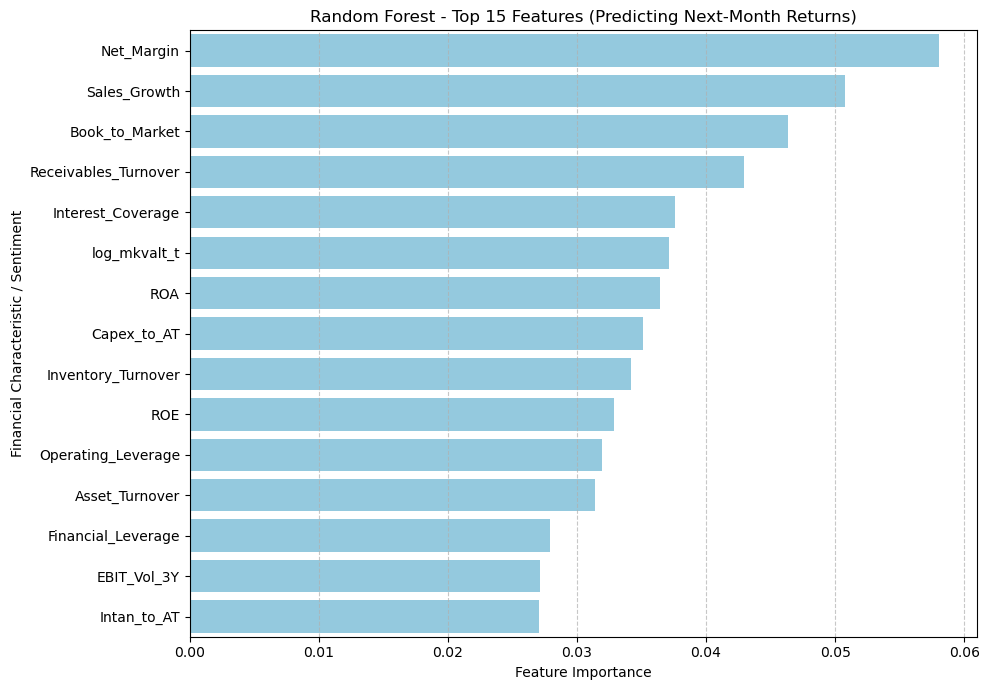

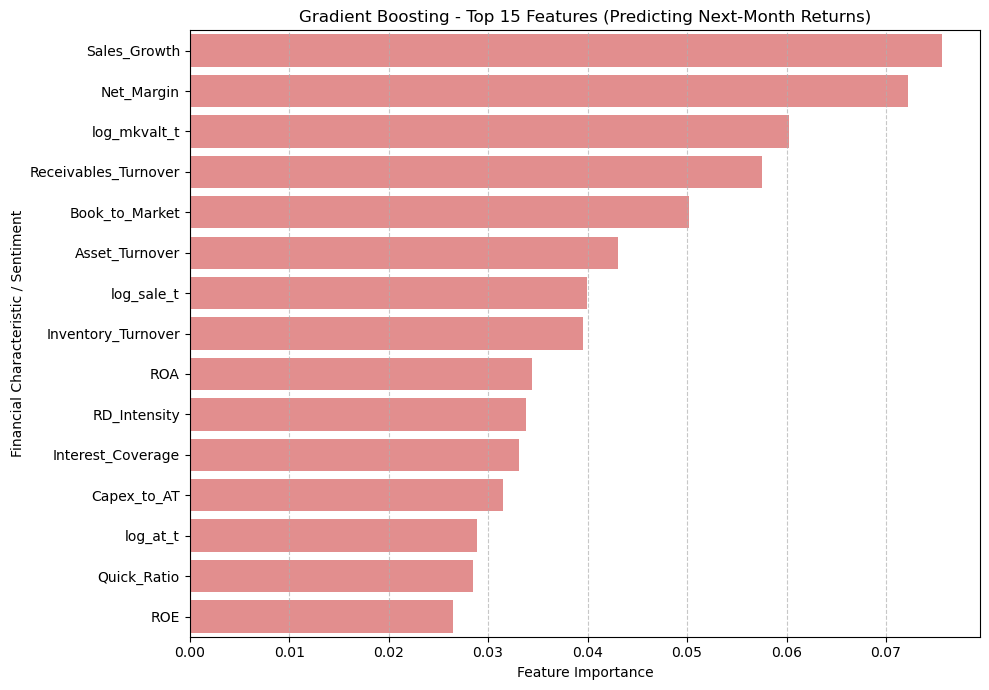


Model Performance Comparison (GKX-Style Monthly Prediction):
|                         | R2        | MSE      | RMSE     |
|:------------------------|:----------|:---------|:---------|
| Random Forest (GKX)     | 0.007469  | 0.018579 | 0.136306 |
| Gradient Boosting (GKX) | 0.004112  | 0.018642 | 0.136537 |
| Neural Network (GKX)    | -0.099374 | 0.020579 | 0.143455 |


In [4]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Load and Prepare Sentiment Data ---
print("--- Loading Loughran-McDonald Sentiment Data ---")
try:
    df_sentiment = pd.read_csv("Loughran-McDonald_10X_Summaries_1993-2024.csv")
    df_sentiment['FILING_DATE'] = pd.to_datetime(df_sentiment['FILING_DATE'], format='%Y%m%d')
    if 'filing_year' not in df_sentiment.columns:
        df_sentiment['filing_year'] = df_sentiment['FILING_DATE'].dt.year

    sentiment_cols_actual = [
        'N_Negative', 'N_Positive', 'N_Uncertainty', 'N_Litigious',
        'N_StrongModal', 'N_WeakModal', 'N_Constraining', 'N_Complexity', 'N_Negation'
    ]
    norm_col = 'N_Words'
    new_norm_cols = []
    for col in sentiment_cols_actual:
        new_col_name = f"{col.replace('N_', 'LM_')}_Norm"
        df_sentiment[new_col_name] = np.where(
            (df_sentiment[norm_col].isna()) | (df_sentiment[norm_col] == 0), 0,
            df_sentiment[col] / df_sentiment[norm_col]
        )
        new_norm_cols.append(new_col_name)

    df_sentiment_select = df_sentiment[['CIK', 'filing_year'] + new_norm_cols].copy()
    df_sentiment_final = df_sentiment_select.sort_values(by=['CIK', 'filing_year']).drop_duplicates(subset=['CIK', 'filing_year'], keep='last')
    print("Sentiment data normalized and prepared.")
except FileNotFoundError:
    print("ERROR: 'Loughran-McDonald_10X_Summaries_1993-2024.csv' not found.")
    raise SystemExit("Sentiment file not found.")
except Exception as e:
    print(f"An error occurred loading/processing the sentiment file: {e}")
    raise SystemExit(f"Error processing sentiment file: {e}")

# --- 2. Load ccm1.csv and Create TWO DataFrames: Annual Chars & Monthly Returns ---
print("\n--- Loading ccm1.csv and creating data panels ---")
try:
    df_ccm_raw = pd.read_csv("ccm1.csv")

    # --- 2a. Create the MONTHLY Returns Panel ---
    df_monthly_returns = df_ccm_raw[['LPERMNO', 'gvkey', 'MthCalDt', 'MthRet']].copy()
    df_monthly_returns = df_monthly_returns.dropna(subset=['LPERMNO', 'MthCalDt', 'MthRet'])
    df_monthly_returns['MthCalDt'] = pd.to_datetime(df_monthly_returns['MthCalDt'])
    df_monthly_returns['merge_year'] = df_monthly_returns['MthCalDt'].dt.year
    df_monthly_returns = df_monthly_returns.drop_duplicates(subset=['LPERMNO', 'MthCalDt'])
    print(f"Created monthly returns panel with {len(df_monthly_returns)} rows.")

    # --- 2b. Create the ANNUAL Characteristics Panel ---
    # Keep only one row per firm-year, prioritizing the last entry if duplicates exist
    df_ccm_annual = df_ccm_raw.sort_values(by=['gvkey', 'datadate']).drop_duplicates(subset=['gvkey', 'fyear'], keep='last').copy()
    df_ccm_annual['datadate'] = pd.to_datetime(df_ccm_annual['datadate'])

    # LAGGED AND AVERAGE VARS
    lag_vars = ['at', 'seq', 'sale', 'ebit', 'invt', 'rect', 'xint']
    for var in lag_vars:
        df_ccm_annual[f'{var}_prev'] = df_ccm_annual.groupby('gvkey')[var].shift(1)
    df_ccm_annual['at_avg'] = (df_ccm_annual['at'] + df_ccm_annual['at_prev']) / 2
    df_ccm_annual['seq_avg'] = (df_ccm_annual['seq'] + df_ccm_annual['seq_prev']) / 2
    df_ccm_annual['invt_avg'] = (df_ccm_annual['invt'] + df_ccm_annual['invt_prev']) / 2
    df_ccm_annual['rect_avg'] = (df_ccm_annual['rect'] + df_ccm_annual['rect_prev']) / 2

    # CALCULATE RATIOS
    df_ccm_annual['Financial_Leverage'] = df_ccm_annual['lt'] / df_ccm_annual['at']
    df_ccm_annual['Current_Ratio'] = df_ccm_annual['act'] / df_ccm_annual['lct']
    df_ccm_annual['Quick_Ratio'] = (df_ccm_annual['act'] - df_ccm_annual['invt']) / df_ccm_annual['lct']
    df_ccm_annual['Debt_to_Equity'] = (df_ccm_annual['dltt'] + df_ccm_annual['dlc']) / df_ccm_annual['seq']
    df_ccm_annual['Interest_Coverage'] = df_ccm_annual['ebit'] / df_ccm_annual['xint']
    df_ccm_annual['Net_Margin'] = df_ccm_annual['ni'] / df_ccm_annual['sale']
    df_ccm_annual['ROA'] = df_ccm_annual['ni'] / df_ccm_annual['at_avg']
    df_ccm_annual['ROE'] = df_ccm_annual['ni'] / df_ccm_annual['seq_avg']
    df_ccm_annual['Sales_Growth'] = (df_ccm_annual['sale'] - df_ccm_annual['sale_prev']) / df_ccm_annual['sale_prev']
    df_ccm_annual['RD_Intensity'] = df_ccm_annual['xrd'] / df_ccm_annual['sale']
    df_ccm_annual['Capex_to_AT'] = df_ccm_annual['capx'] / df_ccm_annual['at']
    df_ccm_annual['EBIT_Vol_3Y'] = df_ccm_annual.groupby('gvkey')['ebit'].rolling(
        window=3, min_periods=3).std().reset_index(level=0, drop=True)
    df_ccm_annual['EBIT_Growth'] = (df_ccm_annual['ebit'] - df_ccm_annual['ebit_prev']) / df_ccm_annual['ebit_prev']
    df_ccm_annual['Operating_Leverage'] = df_ccm_annual['EBIT_Growth'] / df_ccm_annual['Sales_Growth']
    df_ccm_annual['Book_to_Market'] = df_ccm_annual['seq'] / df_ccm_annual['mkvalt']
    df_ccm_annual['Asset_Turnover'] = df_ccm_annual['sale'] / df_ccm_annual['at_avg']
    df_ccm_annual['Inventory_Turnover'] = df_ccm_annual['cogs'] / df_ccm_annual['invt_avg']
    df_ccm_annual['Receivables_Turnover'] = df_ccm_annual['sale'] / df_ccm_annual['rect_avg']
    df_ccm_annual['Intan_to_AT'] = df_ccm_annual['intan'] / df_ccm_annual['at']

    # Add log-transformed predictors
    log_cols = ['at', 'sale', 'ebit', 'xint', 'ni', 'seq', 'mkvalt']
    for col in log_cols:
        df_ccm_annual[f'log_{col}_t'] = np.log(df_ccm_annual[col].abs().replace(0, np.nan))

    # PREPARE ANNUAL CHARACTERISTICS FOR MERGE
    df_ccm_annual['CIK'] = df_ccm_annual['cik'].fillna(0).astype(int)
    # *** THIS IS THE FIX: Handle NaNs in 'fyear' before converting to int ***
    df_ccm_annual['financial_year'] = df_ccm_annual['fyear'].fillna(-1).astype(int)
    # *** END OF FIX ***

    # Merge sentiment into annual characteristics
    df_annual_chars = pd.merge(
        df_ccm_annual,
        df_sentiment_final,
        left_on=['CIK', 'financial_year'],
        right_on=['CIK', 'filing_year'],
        how='left'
    )
    # Fill sentiment NaNs
    for col in new_norm_cols:
         df_annual_chars[col].fillna(0, inplace=True)

    # Define the lag for merging characteristics with returns
    df_annual_chars['merge_year'] = df_annual_chars['financial_year'] + 1

    # Define all predictors
    characteristic_predictors = [
        'Financial_Leverage', 'Current_Ratio', 'Quick_Ratio', 'Debt_to_Equity',
        'Interest_Coverage', 'Net_Margin', 'ROA', 'ROE', 'Sales_Growth',
        'RD_Intensity', 'Capex_to_AT', 'EBIT_Vol_3Y', 'Operating_Leverage',
        'Book_to_Market', 'Asset_Turnover', 'Inventory_Turnover',
        'Receivables_Turnover', 'Intan_to_AT'
    ]
    log_predictors = [f'log_{col}_t' for col in log_cols]
    sentiment_predictors = new_norm_cols
    FINAL_PREDICTORS = log_predictors + characteristic_predictors + sentiment_predictors

    # Select only the columns needed for the final merge
    df_annual_chars_final = df_annual_chars[['gvkey', 'merge_year'] + FINAL_PREDICTORS].copy()
    print("Created annual characteristics panel successfully.")

except FileNotFoundError:
    print("ERROR: 'ccm1.csv' not found.")
    raise SystemExit("Base data file not found.")
except Exception as e:
    print(f"An error occurred creating the data panels: {e}")
    raise SystemExit(f"Error processing base data file: {e}")


# --- 3. MERGE MONTHLY RETURNS WITH LAGGED ANNUAL CHARACTERISTICS ---
print("\n--- Merging monthly returns with lagged annual characteristics ---")

df_panel = pd.merge(
    df_monthly_returns,
    df_annual_chars_final,
    on=['gvkey', 'merge_year'],
    how='inner' # Keep only months with matching lagged characteristics
)
print(f"Final monthly panel created with {len(df_panel)} firm-month observations.")


# --- 4. PREPARE FOR ML (Predicting t+1 MONTHLY Return) ---

df_panel = df_panel.sort_values(by=['LPERMNO', 'MthCalDt']).reset_index(drop=True)

# TARGET VARIABLE (Y): Next Month's Return (MthRet at t+1)
df_panel['MthRet_t1'] = df_panel.groupby('LPERMNO')['MthRet'].shift(-1)

# Clean Data: Drop rows with NaN in the target or any predictor
df_panel.replace([np.inf, -np.inf], np.nan, inplace=True)
ml_df = df_panel.dropna(subset=['MthRet_t1'] + FINAL_PREDICTORS)

X = ml_df[FINAL_PREDICTORS]
Y = ml_df['MthRet_t1']

print(f"Total firm-months for ML: {len(ml_df)}")

# --- 5. TIME-SERIES TRAIN-TEST SPLIT (80/20 on MONTHS) ---
all_dates = sorted(ml_df['MthCalDt'].unique())
split_date_index = int(0.8 * len(all_dates))
split_date = all_dates[split_date_index]

X_train = X[ml_df['MthCalDt'] < split_date]
Y_train = Y[ml_df['MthCalDt'] < split_date]
X_test = X[ml_df['MthCalDt'] >= split_date]
Y_test = Y[ml_df['MthCalDt'] >= split_date]

# WINSORIZE THE DATA
print("Winsorizing data at 1% and 99% levels...")
lower_limits_X = X_train.quantile(0.01)
upper_limits_X = X_train.quantile(0.99)
X_train = X_train.clip(lower=lower_limits_X, upper=upper_limits_X, axis=1)
X_test = X_test.clip(lower=lower_limits_X, upper=upper_limits_X, axis=1)

lower_limit_Y = Y_train.quantile(0.01)
upper_limit_Y = Y_train.quantile(0.99)
Y_train = Y_train.clip(lower=lower_limit_Y, upper=upper_limit_Y)
Y_test = Y_test.clip(lower=lower_limit_Y, upper=upper_limit_Y)

# Scale the data for the Neural Network
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train period ends before: {split_date.strftime('%Y-%m-%d')} ({X_train.shape[0]} observations)")
print(f"Test period starts from: {split_date.strftime('%Y-%m-%d')} ({X_test.shape[0]} observations)")
print("-" * 50)


# --- 6. MACHINE LEARNING MODEL TRAINING AND EVALUATION ---
results_gkx = {}

def evaluate_model_gkx(y_true, y_pred, model_name):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    results_gkx[model_name] = {'R2': r2, 'MSE': mse, 'RMSE': rmse}
    print(f"{model_name} R²: {r2:.6f}, RMSE: {rmse:.4f}")

# A. Random Forest Regressor
print("Training Random Forest...")
rf_model_gkx = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model_gkx.fit(X_train, Y_train)
rf_pred_gkx = rf_model_gkx.predict(X_test)
evaluate_model_gkx(Y_test, rf_pred_gkx, 'Random Forest (GKX)')

# B. Gradient Boosting Regressor
print("Training Gradient Boosting...")
gbr_model_gkx = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gbr_model_gkx.fit(X_train, Y_train)
gbr_pred_gkx = gbr_model_gkx.predict(X_test)
evaluate_model_gkx(Y_test, gbr_pred_gkx, 'Gradient Boosting (GKX)')

# C. Neural Network
print("Training Neural Network (MLP)...")
nn_model_gkx = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=300, solver='adam', random_state=42, early_stopping=True)
nn_model_gkx.fit(X_train_scaled, Y_train)
nn_pred_gkx = nn_model_gkx.predict(X_test_scaled) # Use X_test_scaled
evaluate_model_gkx(Y_test, nn_pred_gkx, 'Neural Network (GKX)')
print("-" * 50)


# --- 7. VISUALIZATION AND INTERPRETATION ---
rf_importance_gkx = pd.Series(rf_model_gkx.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 7))
sns.barplot(x=rf_importance_gkx.values, y=rf_importance_gkx.index, color='skyblue')
plt.title('Random Forest - Top 15 Features (Predicting Next-Month Returns)')
plt.xlabel('Feature Importance')
plt.ylabel('Financial Characteristic / Sentiment')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

gbr_importance_gkx = pd.Series(gbr_model_gkx.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
plt.figure(figsize=(10, 7))
sns.barplot(x=gbr_importance_gkx.values, y=gbr_importance_gkx.index, color='lightcoral')
plt.title('Gradient Boosting - Top 15 Features (Predicting Next-Month Returns)')
plt.xlabel('Feature Importance')
plt.ylabel('Financial Characteristic / Sentiment')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

performance_df_gkx = pd.DataFrame(results_gkx).T
print("\nModel Performance Comparison (GKX-Style Monthly Prediction):")
print(performance_df_gkx.to_markdown(numalign="left", stralign="left", floatfmt=".6f"))

In [2]:
dfb1=pd.read_csv("CAPM.csv")
dfb2=pd.read_csv("FF3.csv")
dfb3=pd.read_csv("Carhart4.csv")
dfb3

,PERMNO,DATE,n,RET,alpha,b_mkt,b_smb,b_hml,b_umd,ivol,tvol,R2,exret,TICKER
0,10001,2001-11-30,60,-0.4329%,0.0019,0.2045,0.1166,0.2787,0.0834,3.5829%,3.7358%,8.0219%,-2.2449%,EWST
1,10001,2000-06-30,60,2.7668%,-0.0045,0.2775,-0.0511,0.0032,0.0549,3.4808%,3.7093%,11.9414%,0.9640%,EWST
2,10001,2003-08-29,60,8.6601%,-0.0032,0.3338,0.4094,0.5259,-0.0585,10.8893%,11.1288%,4.2565%,6.3256%,EWST
3,10001,2000-11-30,60,6.2500%,-0.0030,0.2422,0.0261,0.2958,0.1570,3.5299%,3.6795%,7.9631%,6.7462%,EWST
4,10001,2002-02-28,60,-5.3097%,0.0012,0.1902,0.1446,0.2860,0.0596,3.5068%,3.6526%,7.8201%,-6.0311%,EWST
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1891365,93436,2024-09-30,60,22.1942%,0.0433,2.1238,1.5967,-1.5225,-0.1041,16.0197%,22.0992%,47.4518%,14.2204%,TSLA
1891366,93436,2024-08-30,60,-7.7390%,0.0435,2.1059,1.5363,-1.4600,-0.1731,16.0209%,22.0102%,47.0182%,-7.2173%,TSLA
1891367,93436,2024-07-31,60,17.2781%,0.0437,2.1343,1.4814,-1.4397,-0.1726,15.9831%,21.9947%,47.1941%,12.8445%,TSLA
1891368,93436,2024-06-28,60,11.1186%,0.0427,2.1546,1.3472,-1.4671,-0.1811,15.9624%,21.9537%,47.1336%,3.9361%,TSLA


--- Table 1: Summary Statistics (from GKX-style ml_df) ---
|                     |      count |    mean |     std |        min |     25% |    50% |    75% |        max |
|:--------------------|-----------:|--------:|--------:|-----------:|--------:|-------:|-------:|-----------:|
| MthRet_t1           | 23238.0000 |  0.0132 |  0.1874 |    -0.9169 | -0.0550 | 0.0064 | 0.0695 |    16.2505 |
| log_mkvalt_t        | 23238.0000 |  6.6956 |  2.2853 |    -0.1291 |  5.0893 | 6.7230 | 8.2453 |    14.5269 |
| Book_to_Market      | 23238.0000 |  0.5524 |  0.9015 |   -20.1837 |  0.2327 | 0.4153 | 0.6962 |    45.0926 |
| ROA                 | 23238.0000 | -0.0165 |  0.2784 |   -16.7625 | -0.0273 | 0.0389 | 0.0812 |     4.5090 |
| Debt_to_Equity      | 23238.0000 |  1.5476 | 93.4838 | -1672.5479 |  0.0750 | 0.3804 | 0.8449 | 13380.0000 |
| Asset_Turnover      | 23238.0000 |  1.0935 |  0.7608 |    -0.0025 |  0.6171 | 0.9235 | 1.3699 |     8.9402 |
| Sales_Growth        | 23238.0000 |  0.4645 | 25.826

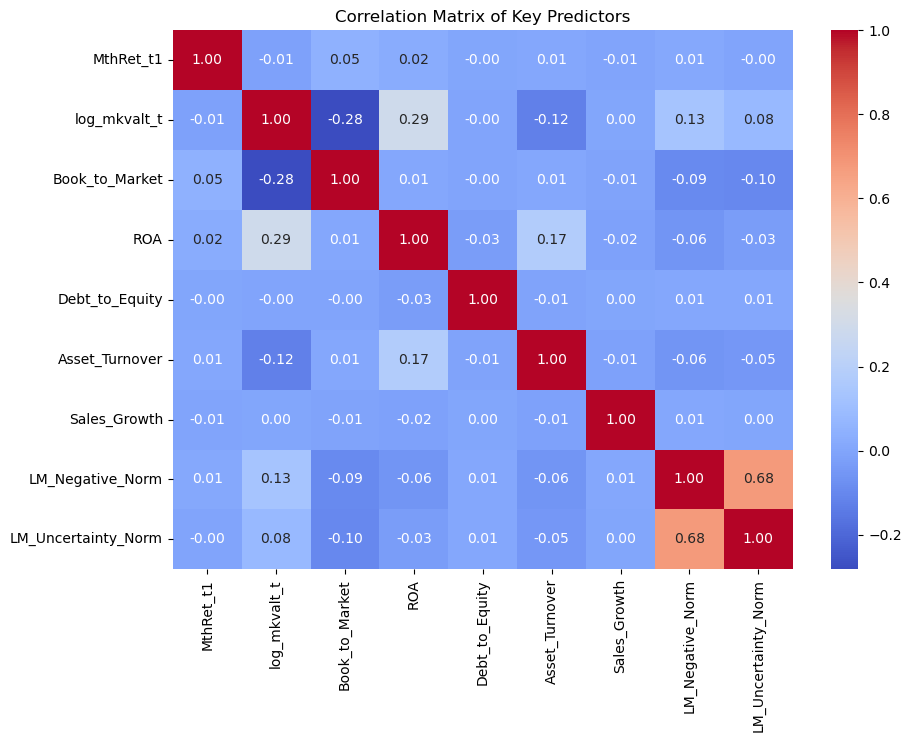



--- Table 3: Linear Model Predictive Performance (OOS R-squared, RMSE) ---
|       |   OOS R-squared |     RMSE |
|:------|----------------:|---------:|
| OLS   |        0.007691 | 0.136291 |
| Ridge |        0.007695 | 0.136291 |


--- Table 4: ML Model Performance & Feature Importance ---
ML Model Predictive Performance (OOS R-squared, RMSE):
|                   |   OOS R-squared |     RMSE |
|:------------------|----------------:|---------:|
| Random Forest     |        0.007469 | 0.136306 |
| Gradient Boosting |        0.004112 | 0.136537 |

Top 15 Feature Importances (Gradient Boosting):
| Feature              |   Importance |
|:---------------------|-------------:|
| Sales_Growth         |       0.0757 |
| Net_Margin           |       0.0722 |
| log_mkvalt_t         |       0.0603 |
| Receivables_Turnover |       0.0575 |
| Book_to_Market       |       0.0502 |
| Asset_Turnover       |       0.0430 |
| log_sale_t           |       0.0399 |
| Inventory_Turnover   |       0.0395 

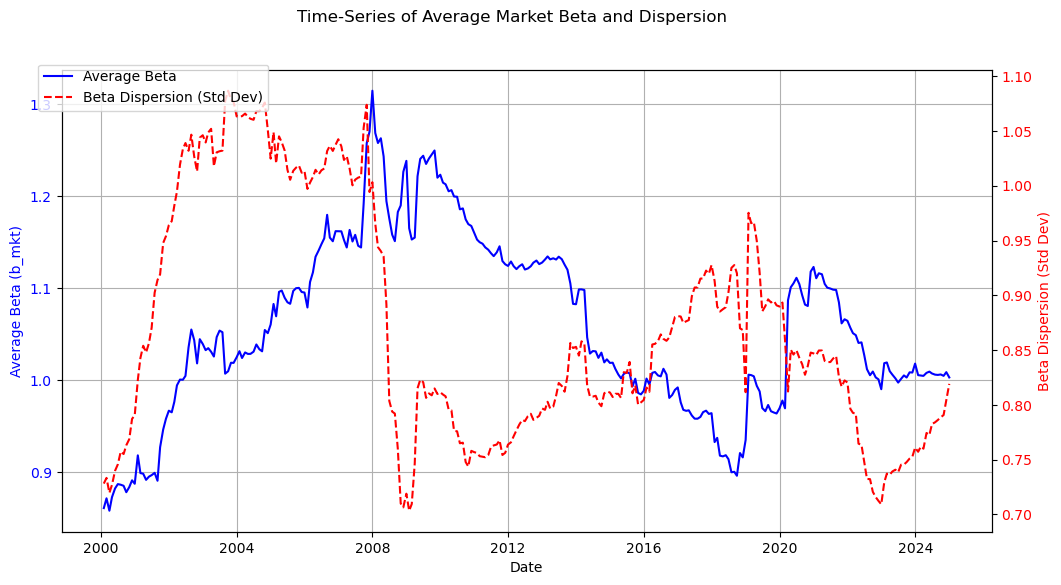



--- Figure 2: Partial Dependence Plots (Gradient Boosting) ---
Note: This may take a moment to compute...


<Figure size 1200x800 with 0 Axes>

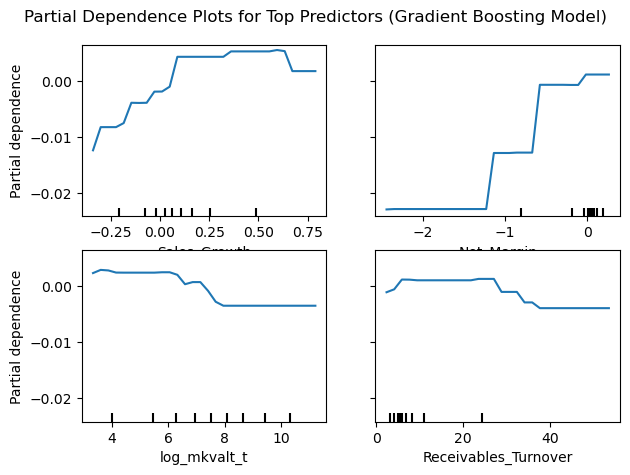

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.inspection import PartialDependenceDisplay

# --- Preamble: Ensure necessary data is clean ---

# Clean dfb1 for Figure 1 (handling '%' in RET and NAs)
# This is a precaution in case it wasn't cleaned before
if 'RET' in dfb1.columns and dfb1['RET'].dtype == 'object':
    dfb1['RET_cleaned'] = dfb1['RET'].str.replace('%', '', regex=False)
    dfb1['RET_cleaned'] = pd.to_numeric(dfb1['RET_cleaned'], errors='coerce') / 100.0
else:
    # If RET is not object, assume it's already numeric (or was handled)
    if 'RET' in dfb1.columns:
        dfb1['RET_cleaned'] = pd.to_numeric(dfb1['RET'], errors='coerce') / 100.0

dfb1['b_mkt_cleaned'] = pd.to_numeric(dfb1['b_mkt'], errors='coerce')
dfb1['DATE_cleaned'] = pd.to_datetime(dfb1['DATE'])


# --- Table 1: Summary Statistics of Key Variables ---
print("--- Table 1: Summary Statistics (from GKX-style ml_df) ---")

# Select a subset of key predictors (your list is very large)
key_vars = [
    'MthRet_t1', # The target
    'log_mkvalt_t', 'Book_to_Market', 'ROA', 'Debt_to_Equity', 
    'Asset_Turnover', 'Sales_Growth', 'LM_Negative_Norm', 'LM_Uncertainty_Norm'
]
# Ensure these key_vars exist in the ml_df
key_vars_exist = [var for var in key_vars if var in ml_df.columns]
summary_stats = ml_df[key_vars_exist].describe().T

print(summary_stats.to_markdown(floatfmt=".4f"))
print("\n" + "="*80 + "\n")


# --- Table 2: Correlation Matrix of Betas and Traits ---
print("--- Table 2: Correlation Matrix (from GKX-style ml_df) ---")

# Using the same key variables from Table 1
correlation_matrix = ml_df[key_vars_exist].corr()

print(correlation_matrix.to_markdown(floatfmt=".3f"))

# Optional: Plot a heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Key Predictors")
plt.show()
print("\n" + "="*80 + "\n")


# --- Table 3: OLS / Ridge Predictive Performance ---
print("--- Table 3: Linear Model Predictive Performance (OOS R-squared, RMSE) ---")

# 1. Train OLS (Linear Regression) as another benchmark
ols_model = LinearRegression()
ols_model.fit(X_train_scaled, Y_train) # Use scaled data
ols_pred = ols_model.predict(X_test_scaled)

# 2. Train Ridge (if not already trained, or retrain for clarity)
ridge_model = Ridge(alpha=1.0) # Using a default alpha
ridge_model.fit(X_train_scaled, Y_train)
ridge_pred = ridge_model.predict(X_test_scaled)

# 3. Calculate metrics
performance_linear = {
    'OLS': {
        'OOS R-squared': r2_score(Y_test, ols_pred),
        'RMSE': np.sqrt(mean_squared_error(Y_test, ols_pred))
    },
    'Ridge': {
        'OOS R-squared': r2_score(Y_test, ridge_pred),
        'RMSE': np.sqrt(mean_squared_error(Y_test, ridge_pred))
    }
}
df_linear_perf = pd.DataFrame(performance_linear).T
print(df_linear_perf.to_markdown(floatfmt=".6f"))
print("\n" + "="*80 + "\n")


# --- Table 4: Random Forest / Gradient Boosting Results + Feature Importance ---
print("--- Table 4: ML Model Performance & Feature Importance ---")

# 1. Performance (R-squared, RMSE)
# (Assuming rf_model_gkx and gbr_model_gkx are the trained models)
rf_pred_gkx = rf_model_gkx.predict(X_test)
gbr_pred_gkx = gbr_model_gkx.predict(X_test)

performance_ml = {
    'Random Forest': {
        'OOS R-squared': r2_score(Y_test, rf_pred_gkx),
        'RMSE': np.sqrt(mean_squared_error(Y_test, rf_pred_gkx))
    },
    'Gradient Boosting': {
        'OOS R-squared': r2_score(Y_test, gbr_pred_gkx),
        'RMSE': np.sqrt(mean_squared_error(Y_test, gbr_pred_gkx))
    }
}
df_ml_perf = pd.DataFrame(performance_ml).T
print("ML Model Predictive Performance (OOS R-squared, RMSE):")
print(df_ml_perf.to_markdown(floatfmt=".6f"))

# 2. Feature Importance
print("\nTop 15 Feature Importances (Gradient Boosting):")
gbr_importance = pd.Series(gbr_model_gkx.feature_importances_, index=FINAL_PREDICTORS)
print(gbr_importance.nlargest(15).to_markdown(floatfmt=".4f", headers=['Feature', 'Importance']))
print("\n" + "="*80 + "\n")


# --- Figure 1: Time-series of Average Beta and Dispersion ---
print("--- Figure 1: Time-Series of Market Beta (Mean and Dispersion) ---")

# Use the cleaned dfb1
dfb1_ts = dfb1.dropna(subset=['DATE_cleaned', 'b_mkt_cleaned'])

# Group by date and calculate mean and std dev (dispersion)
ts_beta = dfb1_ts.groupby('DATE_cleaned')['b_mkt_cleaned'].agg(['mean', 'std']).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot mean beta
ax1.plot(ts_beta['DATE_cleaned'], ts_beta['mean'], color='blue', label='Average Beta')
ax1.set_xlabel('Date')
ax1.set_ylabel('Average Beta (b_mkt)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.grid(True)

# Create a second y-axis for dispersion
ax2 = ax1.twinx()
ax2.plot(ts_beta['DATE_cleaned'], ts_beta['std'], color='red', linestyle='--', label='Beta Dispersion (Std Dev)')
ax2.set_ylabel('Beta Dispersion (Std Dev)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

fig.suptitle('Time-Series of Average Market Beta and Dispersion')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.show()
print("\n" + "="*80 + "\n")


# --- Figure 2: Partial Dependence Plots for Top Predictors ---
print("--- Figure 2: Partial Dependence Plots (Gradient Boosting) ---")
print("Note: This may take a moment to compute...")

# Identify top predictors from the GBR model
top_predictors = gbr_importance.nlargest(4).index.tolist() # Get top 4

# Use a *sample* of the test data for speed
X_test_sample = X_test.sample(n=1000, random_state=1)

# Generate and display the plots
plt.figure(figsize=(12, 8))
fig = PartialDependenceDisplay.from_estimator(
    gbr_model_gkx,
    X_test_sample,
    features=top_predictors, # List of features to plot
    n_cols=2,                 # Arrange in 2 columns
    grid_resolution=30        # Number of points in the x-axis
)
fig.figure_.suptitle('Partial Dependence Plots for Top Predictors (Gradient Boosting Model)')
plt.tight_layout()
plt.show()

--- SCRIPT START ---

--- Task 1: Loading Pre-computed Betas from dfb1 ---
  Successfully processed dfb1 data. 1891040 beta observations loaded.

--- Task 2: Merging Betas with Characteristics (Robust Annual Lag Method) ---
  2a. Creating annual characteristics panel...
  2b. Loading and merging sentiment data...
  2c. Merging beta and characteristics panels...
  Final merged panel created with 1521353 firm-month observations.

--- Task 3: Predicting Next-Period Beta Level ---
  Evaluating models for Beta Level prediction...
  Training OLS...
  Training Ridge...
  Training RF...
  Training GBR...

Model Performance (Beta Level Prediction):
|       |   R-squared |   RMSE |    MAE |
|:------|------------:|-------:|-------:|
| OLS   |     -0.0197 | 0.7284 | 0.5194 |
| Ridge |     -0.0197 | 0.7284 | 0.5194 |
| RF    |      0.0469 | 0.7042 | 0.4880 |
| GBR   |      0.0797 | 0.6920 | 0.4794 |


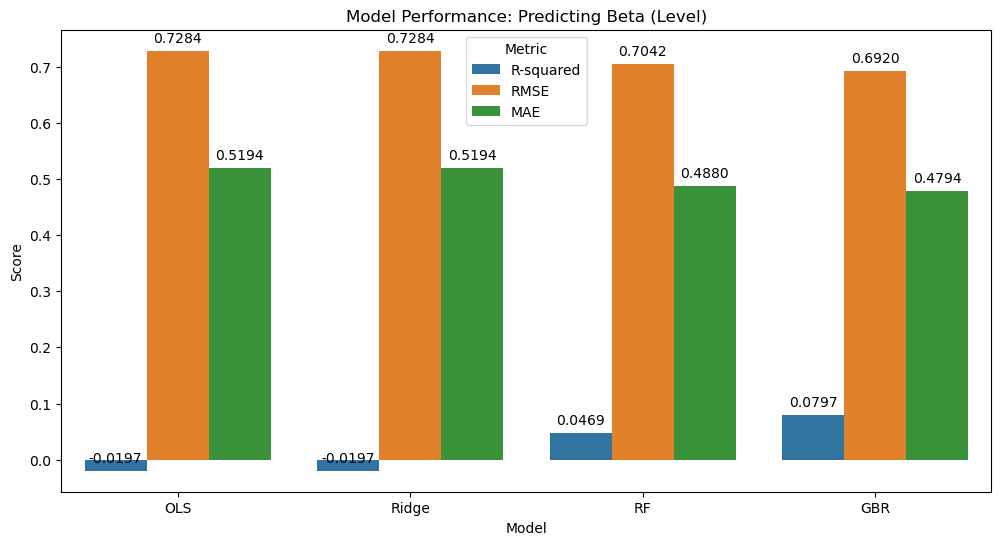


--- Task 4: Predicting Next-Period Beta Change ---
  Evaluating models for Beta Change prediction...
  Training OLS...
  Training Ridge...
  Training RF...
  Training GBR...

Model Performance (Beta Change Prediction):
|       |   R-squared |   RMSE |    MAE |
|:------|------------:|-------:|-------:|
| OLS   |      0.0025 | 0.0816 | 0.0371 |
| Ridge |      0.0025 | 0.0816 | 0.0371 |
| RF    |     -0.0672 | 0.0844 | 0.0383 |
| GBR   |     -0.0516 | 0.0837 | 0.0380 |


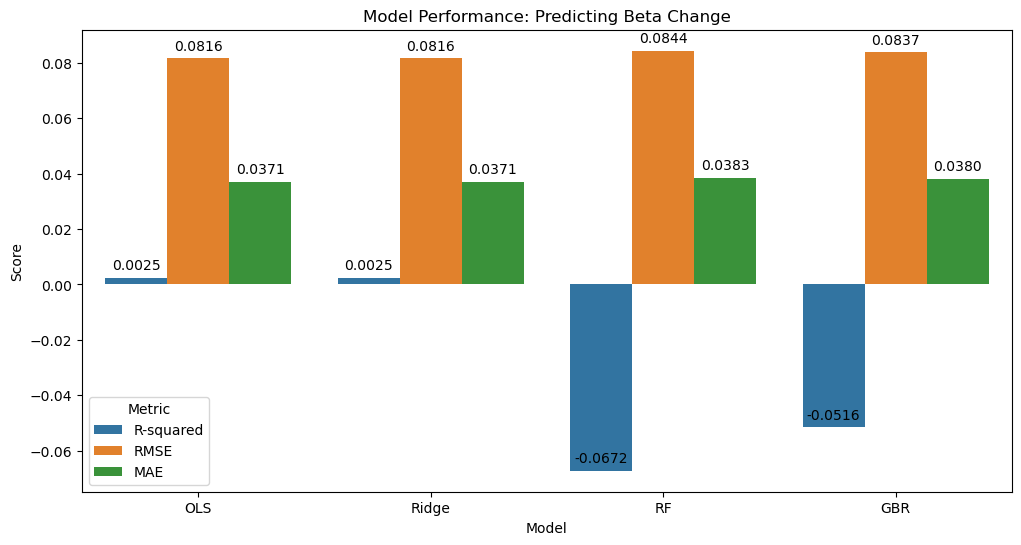

  Plotting feature importance for Beta Change models...


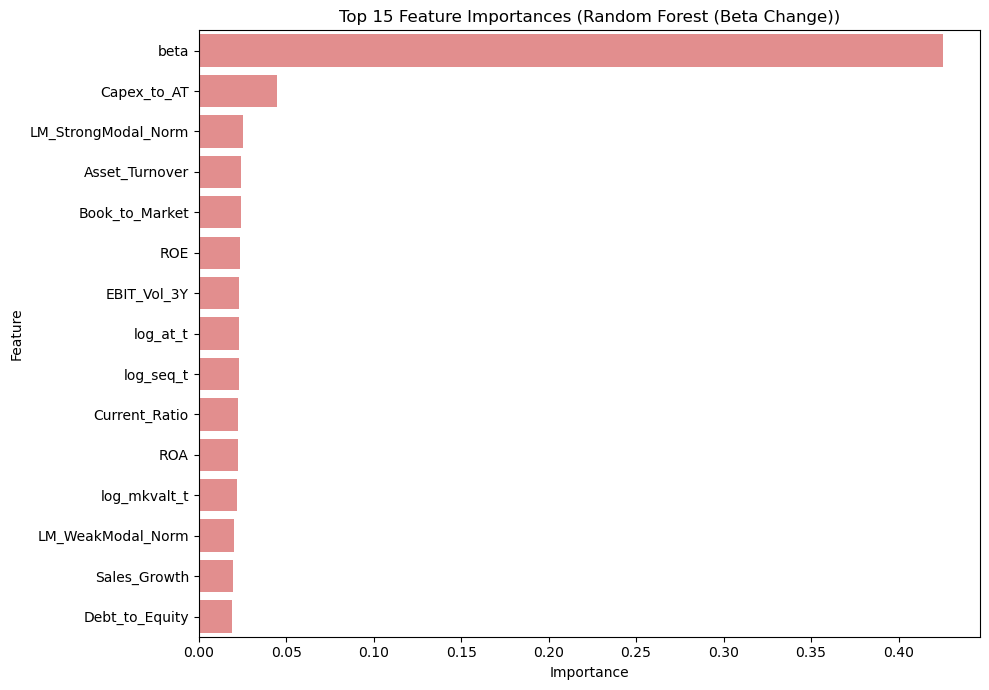

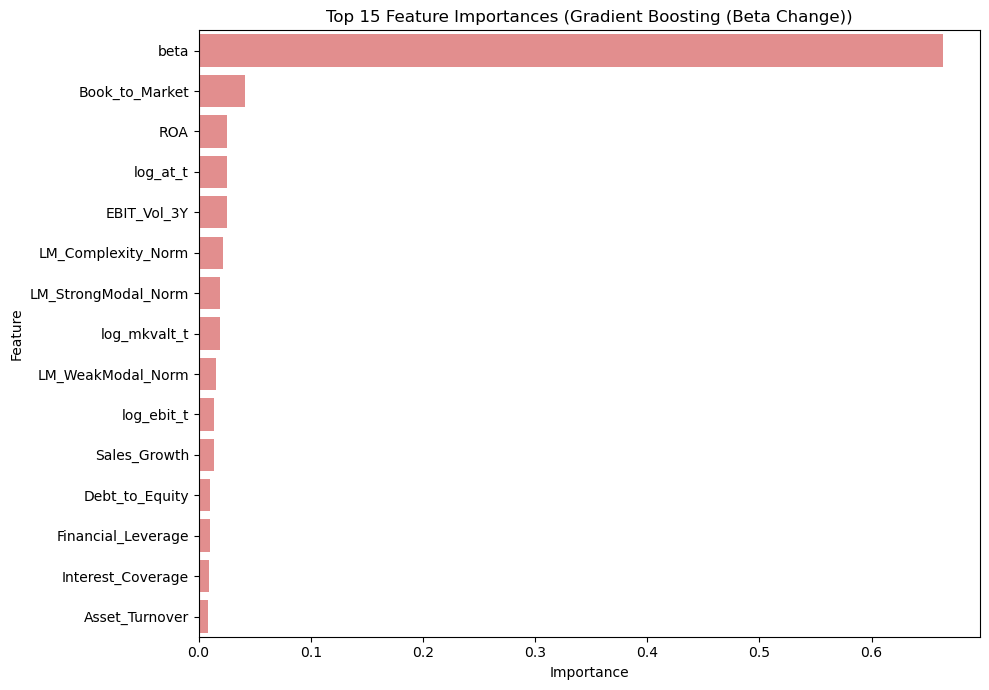


--- Task 5: Additional Visualizations ---
  Plotting Beta Distribution Over Time...


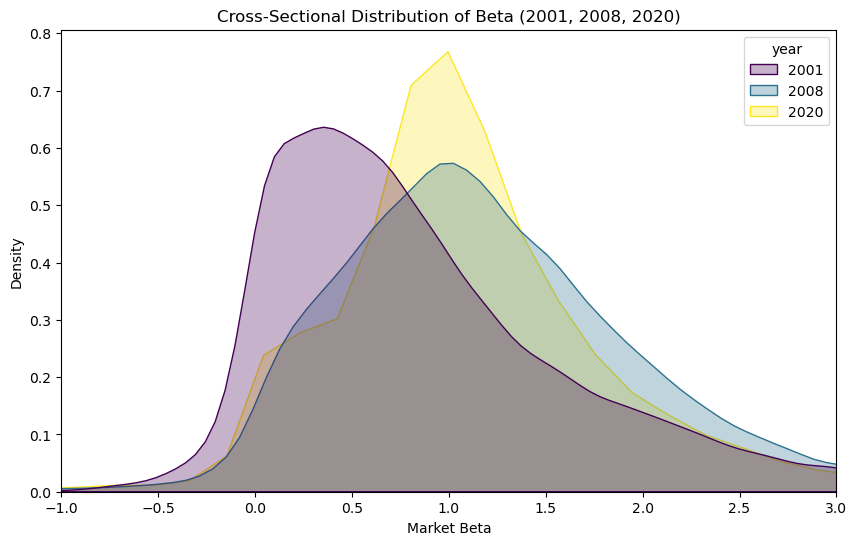

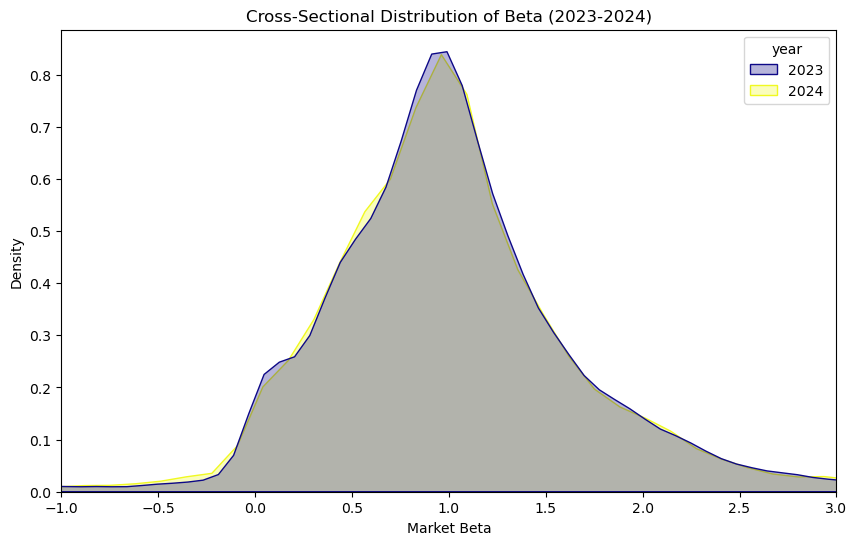

  Calculating Beta Persistence...
FATAL ERROR in Task 5: 'SeriesGroupBy' object has no attribute 'autocorr'.

--- SCRIPT COMPLETE ---


In [23]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')
# Register tqdm for pandas .apply()
tqdm.pandas()

print("--- SCRIPT START ---")

# === TASK 1: LOAD PRE-COMPUTED BETAS (from dfb1) ===
print("\n--- Task 1: Loading Pre-computed Betas from dfb1 ---")

try:
    # --- OPTION A: If 'dfb1' is a variable in your notebook ---
    # Make sure your dfb1 variable is loaded, then uncomment the next line:
    # dfb1_data = dfb1.copy() 
    
    # --- OPTION B: If 'dfb1' is a CSV file you can load ---
    # Comment this line out if you used Option A
    dfb1_data = dfb1 # Assumes a CSV file named dfb1.csv
    
    # --- Clean and Prepare dfb1_data ---
    # Rename columns to be consistent
    dfb1_data.rename(columns={
        'PERMNO': 'LPERMNO', 
        'DATE_cleaned': 'date', # Use the cleaned date column
        'DATE': 'date_orig',
        'b_mkt': 'beta'
    }, inplace=True, errors='ignore') # ignore errors if columns don't exist
    
    # If 'date' (from DATE_cleaned) doesn't exist, create it
    if 'date' not in dfb1_data.columns:
        dfb1_data['date'] = pd.to_datetime(dfb1_data.get('date_orig', dfb1_data.get('DATE')), errors='coerce')
        
    # Ensure key columns are numeric
    dfb1_data['LPERMNO'] = pd.to_numeric(dfb1_data['LPERMNO'], errors='coerce')
    dfb1_data['beta'] = pd.to_numeric(dfb1_data['beta'], errors='coerce')
    
    # Keep only essential columns
    df_betas_monthly = dfb1_data[['LPERMNO', 'date', 'beta']].copy()
    
    # Drop any rows where key info is missing
    df_betas_monthly.dropna(subset=['LPERMNO', 'date', 'beta'], inplace=True)
    
    # Sort and create lag/change variables
    df_betas_monthly = df_betas_monthly.sort_values(by=['LPERMNO', 'date'])
    df_betas_monthly['beta_lag'] = df_betas_monthly.groupby('LPERMNO')['beta'].shift(1)
    df_betas_monthly['beta_change'] = df_betas_monthly['beta'] - df_betas_monthly['beta_lag']
    
    # Save the cleaned, ready-to-merge betas to a new file (optional, but good practice)
    df_betas_monthly.to_csv("rolling_betas_from_dfb1.csv", index=False)
    print(f"  Successfully processed dfb1 data. {len(df_betas_monthly)} beta observations loaded.")

except FileNotFoundError:
    print("FATAL ERROR: 'dfb1.csv' not found. Make sure the file is in the directory, or load 'dfb1' as a variable.")
    raise SystemExit
except NameError:
    print("FATAL ERROR: 'dfb1' variable not found in memory and 'dfb1.csv' not loaded.")
    print("Please either load 'dfb1.csv' or ensure the 'dfb1' DataFrame is in your notebook environment.")
    raise SystemExit
except Exception as e:
    print(f"FATAL ERROR processing dfb1: {e}. Aborting.")
    raise SystemExit

# Load ccm1.csv for characteristics
try:
    df_ccm_raw = pd.read_csv("ccm1.csv")
except FileNotFoundError:
    print("FATAL ERROR: ccm1.csv not found. Aborting.")
    raise SystemExit

# === TASK 2: MERGE ROLLING BETAS WITH CHARACTERISTICS (ROBUST) ===
print("\n--- Task 2: Merging Betas with Characteristics (Robust Annual Lag Method) ---")

def create_full_panel_robust(df_ccm_raw, df_betas_monthly):
    # --- 2a. Create Annual Characteristics Panel ---
    print("  2a. Creating annual characteristics panel...")
    df_ccm_annual = df_ccm_raw.sort_values(by=['gvkey', 'fyear']).drop_duplicates(subset=['gvkey', 'fyear'], keep='last').copy()
    df_ccm_annual.dropna(subset=['fyear'], inplace=True)
    df_ccm_annual['financial_year'] = df_ccm_annual['fyear'].astype(int)
    
    # LAGGED AND AVERAGE VARS
    df_ccm_annual = df_ccm_annual.sort_values(by=['gvkey', 'financial_year'])
    lag_vars = ['at', 'seq', 'sale', 'ebit', 'invt', 'rect', 'xint']
    for var in lag_vars:
        df_ccm_annual[f'{var}_prev'] = df_ccm_annual.groupby('gvkey')[var].shift(1)
    df_ccm_annual['at_avg'] = (df_ccm_annual['at'] + df_ccm_annual['at_prev']) / 2
    df_ccm_annual['seq_avg'] = (df_ccm_annual['seq'] + df_ccm_annual['seq_prev']) / 2
    df_ccm_annual['invt_avg'] = (df_ccm_annual['invt'] + df_ccm_annual['invt_prev']) / 2
    df_ccm_annual['rect_avg'] = (df_ccm_annual['rect'] + df_ccm_annual['rect_prev']) / 2

    # CALCULATE RATIOS
    df_ccm_annual['Financial_Leverage'] = df_ccm_annual['lt'] / df_ccm_annual['at']
    df_ccm_annual['Current_Ratio'] = df_ccm_annual['act'] / df_ccm_annual['lct']
    df_ccm_annual['Quick_Ratio'] = (df_ccm_annual['act'] - df_ccm_annual['invt']) / df_ccm_annual['lct']
    df_ccm_annual['Debt_to_Equity'] = (df_ccm_annual['dltt'] + df_ccm_annual['dlc']) / df_ccm_annual['seq']
    df_ccm_annual['Interest_Coverage'] = df_ccm_annual['ebit'] / df_ccm_annual['xint']
    df_ccm_annual['Net_Margin'] = df_ccm_annual['ni'] / df_ccm_annual['sale']
    df_ccm_annual['ROA'] = df_ccm_annual['ni'] / df_ccm_annual['at_avg']
    df_ccm_annual['ROE'] = df_ccm_annual['ni'] / df_ccm_annual['seq_avg']
    df_ccm_annual['Sales_Growth'] = (df_ccm_annual['sale'] - df_ccm_annual['sale_prev']) / df_ccm_annual['sale_prev']
    df_ccm_annual['RD_Intensity'] = df_ccm_annual['xrd'] / df_ccm_annual['sale']
    df_ccm_annual['Capex_to_AT'] = df_ccm_annual['capx'] / df_ccm_annual['at']
    df_ccm_annual['EBIT_Vol_3Y'] = df_ccm_annual.groupby('gvkey')['ebit'].rolling(
        window=3, min_periods=3).std().reset_index(level=0, drop=True)
    df_ccm_annual['EBIT_Growth'] = (df_ccm_annual['ebit'] - df_ccm_annual['ebit_prev']) / df_ccm_annual['ebit_prev']
    df_ccm_annual['Operating_Leverage'] = df_ccm_annual['EBIT_Growth'] / df_ccm_annual['Sales_Growth']
    df_ccm_annual['Book_to_Market'] = df_ccm_annual['seq'] / df_ccm_annual['mkvalt']
    df_ccm_annual['Asset_Turnover'] = df_ccm_annual['sale'] / df_ccm_annual['at_avg']
    df_ccm_annual['Inventory_Turnover'] = df_ccm_annual['cogs'] / df_ccm_annual['invt_avg']
    df_ccm_annual['Receivables_Turnover'] = df_ccm_annual['sale'] / df_ccm_annual['rect_avg']
    df_ccm_annual['Intan_to_AT'] = df_ccm_annual['intan'] / df_ccm_annual['at']
    
    global log_predictors
    log_cols = ['at', 'sale', 'ebit', 'xint', 'ni', 'seq', 'mkvalt']
    log_predictors = []
    for col in log_cols:
        col_name = f'log_{col}_t'
        df_ccm_annual[col_name] = np.log(df_ccm_annual[col].abs().replace(0, np.nan))
        log_predictors.append(col_name)

    # --- 2b. Load and Merge Sentiment Data ---
    print("  2b. Loading and merging sentiment data...")
    try:
        df_sentiment = pd.read_csv("Loughran-McDonald_10X_Summaries_1993-2024.csv")
        df_sentiment['FILING_DATE'] = pd.to_datetime(df_sentiment['FILING_DATE'], format='%Y%m%d')
        if 'filing_year' not in df_sentiment.columns:
            df_sentiment['filing_year'] = df_sentiment['FILING_DATE'].dt.year

        global sentiment_predictors
        sentiment_cols_actual = ['N_Negative', 'N_Positive', 'N_Uncertainty', 'N_Litigious', 
                                 'N_StrongModal', 'N_WeakModal', 'N_Constraining', 'N_Complexity', 'N_Negation']
        norm_col = 'N_Words'
        sentiment_predictors = []
        for col in sentiment_cols_actual:
            new_col_name = f"{col.replace('N_', 'LM_')}_Norm"
            df_sentiment[new_col_name] = np.where(
                (df_sentiment[norm_col].isna()) | (df_sentiment[norm_col] == 0), 0,
                df_sentiment[col] / df_sentiment[norm_col]
            )
            sentiment_predictors.append(new_col_name)
        df_sentiment_final = df_sentiment[['CIK', 'filing_year'] + sentiment_predictors].copy()
        df_sentiment_final.dropna(subset=['filing_year'], inplace=True)
        df_sentiment_final['filing_year'] = df_sentiment_final['filing_year'].astype(int)
        df_sentiment_final = df_sentiment_final.sort_values(by=['CIK', 'filing_year']).drop_duplicates(subset=['CIK', 'filing_year'], keep='last')
    except FileNotFoundError:
        print("  WARNING: Sentiment file not found. Proceeding without sentiment features.")
        sentiment_predictors = [] # Ensure list is empty

    # Merge sentiment into annual characteristics
    df_ccm_annual['CIK'] = df_ccm_annual['cik'].fillna(0).astype(int)
    if 'filing_year' in locals().get('df_sentiment_final', pd.DataFrame()).columns:
        df_annual_chars = pd.merge(df_ccm_annual, df_sentiment_final, 
                                   left_on=['CIK', 'financial_year'], right_on=['CIK', 'filing_year'], how='left')
    else:
        df_annual_chars = df_ccm_annual.copy() # No sentiment file
        
    for col in sentiment_predictors:
         if col in df_annual_chars.columns:
             df_annual_chars[col].fillna(0, inplace=True)
         
    global characteristic_predictors
    characteristic_predictors = [
        'Financial_Leverage', 'Current_Ratio', 'Quick_Ratio', 'Debt_to_Equity', 'Interest_Coverage', 
        'Net_Margin', 'ROA', 'ROE', 'Sales_Growth', 'RD_Intensity', 'Capex_to_AT', 'EBIT_Vol_3Y', 
        'Operating_Leverage', 'Book_to_Market', 'Asset_Turnover', 'Inventory_Turnover', 
        'Receivables_Turnover', 'Intan_to_AT'
    ]
    global FINAL_PREDICTORS
    FINAL_PREDICTORS = log_predictors + characteristic_predictors + sentiment_predictors
    
    # This is the final characteristics panel
    df_annual_chars_final = df_annual_chars[['gvkey', 'financial_year'] + FINAL_PREDICTORS].copy()
    
    # --- 2c. Merge Beta Panel with Characteristics Panel ---
    print("  2c. Merging beta and characteristics panels...")
    
    # Create the merge key on the monthly beta data
    df_betas_monthly['merge_year'] = df_betas_monthly['date'].dt.year
    # Create the key for the *lagged* characteristics (t-1)
    df_betas_monthly['financial_year'] = df_betas_monthly['merge_year'] - 1

    # Create the LPERMNO <-> gvkey link table from the raw data
    link_table = df_ccm_raw[['LPERMNO', 'gvkey']].dropna().drop_duplicates()
    link_table['LPERMNO'] = link_table['LPERMNO'].astype(int)
    link_table['gvkey'] = link_table['gvkey'].astype(int)

    # Merge gvkey into the beta panel using LPERMNO
    df_betas_monthly['LPERMNO'] = df_betas_monthly['LPERMNO'].astype(int)
    df_betas_with_gvkey = pd.merge(df_betas_monthly, link_table, on='LPERMNO', how='left')
    df_betas_with_gvkey.dropna(subset=['gvkey'], inplace=True) # Drop betas without a gvkey match
    
    # Now merge the two panels on the clean keys
    df_panel_final = pd.merge(
        df_betas_with_gvkey,
        df_annual_chars_final,
        on=['gvkey', 'financial_year'], # Merge on gvkey and lagged year
        how='inner' # Keep only firm-months with matching lagged chars
    )
    
    # Clean infinities that may have come from ratios
    df_panel_final.replace([np.inf, -np.inf], np.nan, inplace=True)
    
    print(f"  Final merged panel created with {len(df_panel_final)} firm-month observations.")
    return df_panel_final

# Run Task 2
try:
    df_panel_beta = create_full_panel_robust(df_ccm_raw, df_betas_monthly)
    if len(df_panel_beta) == 0:
        print("FATAL ERROR: Merge resulted in 0 observations. Check data alignment.")
        raise SystemExit
except Exception as e:
    print(f"FATAL ERROR in Task 2: {e}. Aborting.")
    raise SystemExit
    
# === TASK 3: PREDICT NEXT-PERIOD BETA (LEVEL) ===
print("\n--- Task 3: Predicting Next-Period Beta Level ---")

# --- Helper Function for Model Evaluation ---
def evaluate_models(X_train, Y_train, X_test, Y_test, model_dict):
    """
    Trains and evaluates a dictionary of models.
    Returns a DataFrame of performance and a dictionary of trained models.
    """
    performance = {}
    trained_models = {}
    
    # Scale data for linear/NN models
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    for name, model in model_dict.items():
        print(f"  Training {name}...")
        try:
            if name == 'Neural Network':
                model.fit(X_train_scaled, Y_train)
                preds = model.predict(X_test_scaled)
            elif name in ['OLS', 'Ridge']:
                model.fit(X_train_scaled, Y_train)
                preds = model.predict(X_test_scaled)
            else: # Tree models
                model.fit(X_train, Y_train)
                preds = model.predict(X_test)
            
            r2 = r2_score(Y_test, preds)
            rmse = np.sqrt(mean_squared_error(Y_test, preds))
            mae = mean_absolute_error(Y_test, preds)
            performance[name] = {'R-squared': r2, 'RMSE': rmse, 'MAE': mae}
            trained_models[name] = model # Save the trained model
        except Exception as e:
            print(f"    Failed to train {name}: {e}")
            performance[name] = {'R-squared': np.nan, 'RMSE': np.nan, 'MAE': np.nan}
            trained_models[name] = None
            
    return pd.DataFrame(performance).T, trained_models

# --- Helper Function for Plotting Performance ---
def plot_performance_chart(df_perf, title):
    df_perf_plot = df_perf.reset_index().melt(id_vars='index', var_name='Metric', value_name='Score')
    plt.figure(figsize=(12, 6))
    g = sns.barplot(data=df_perf_plot, x='index', y='Score', hue='Metric')
    plt.title(title)
    plt.ylabel('Score')
    plt.xlabel('Model')
    plt.legend(title='Metric')
    # Add labels on top of bars
    for p in g.patches:
        g.annotate(format(p.get_height(), '.4f'), 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')
    plt.show()

# --- Helper Function for Feature Importance ---
def plot_feature_importance(model, model_name, features, top_n=15):
    if model and hasattr(model, 'feature_importances_'):
        importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False).head(top_n)
        plt.figure(figsize=(10, 7))
        sns.barplot(x=importances.values, y=importances.index, color='skyblue' if 'RF' in model_name else 'lightcoral')
        plt.title(f'Top {top_n} Feature Importances ({model_name})')
        plt.xlabel('Importance')
        plt.ylabel('Feature')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Cannot plot feature importance for {model_name} (model not trained or no .feature_importances_ attribute).")

try:
    # 1. Prepare data
    df_task3 = df_panel_beta.copy()
    df_task3 = df_task3.sort_values(by=['LPERMNO', 'date'])
    df_task3['target_beta_t1'] = df_task3.groupby('LPERMNO')['beta'].shift(-1)
    df_task3.replace([np.inf, -np.inf], np.nan, inplace=True)
    df_task3 = df_task3.dropna(subset=['target_beta_t1'] + FINAL_PREDICTORS)

    # 2. Split data
    X = df_task3[FINAL_PREDICTORS]
    Y = df_task3['target_beta_t1']
    
    if X.empty:
        raise ValueError("No data available for Task 3 after cleaning. Check merge.")
        
    all_dates_3 = sorted(df_task3['date'].unique())
    split_date_3 = all_dates_3[int(0.8 * len(all_dates_3))]
    X_train_3 = X[df_task3['date'] < split_date_3]
    Y_train_3 = Y[df_task3['date'] < split_date_3]
    X_test_3 = X[df_task3['date'] >= split_date_3]
    Y_test_3 = Y[df_task3['date'] >= split_date_3]
    
    if X_train_3.empty or X_test_3.empty:
        raise ValueError(f"Train/Test split failed for Task 3. Train size: {len(X_train_3)}, Test size: {len(X_test_3)}")

    # 3. Define Models
    models_3_dict = {
        'OLS': LinearRegression(),
        'Ridge': Ridge(alpha=1.0),
        'RF': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
        'GBR': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
    }

    # 4. Run and Evaluate
    print("  Evaluating models for Beta Level prediction...")
    df_perf_3, trained_models_3 = evaluate_models(X_train_3, Y_train_3, X_test_3, Y_test_3, models_3_dict)
    print("\nModel Performance (Beta Level Prediction):")
    print(df_perf_3.to_markdown(floatfmt=".4f"))
    plot_performance_chart(df_perf_3, "Model Performance: Predicting Beta (Level)")

except Exception as e:
    print(f"FATAL ERROR in Task 3: {e}.")


# === TASK 4: PREDICT NEXT-PERIOD BETA CHANGE ===
print("\n--- Task 4: Predicting Next-Period Beta Change ---")
try:
    # 1. Prepare data
    df_task4 = df_panel_beta.copy()
    df_task4 = df_task4.sort_values(by=['LPERMNO', 'date'])
    df_task4['target_beta_change_t1'] = df_task4.groupby('LPERMNO')['beta_change'].shift(-1)
    df_task4.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Define predictors *including* current beta
    predictors_4 = FINAL_PREDICTORS + ['beta']
    df_task4 = df_task4.dropna(subset=['target_beta_change_t1'] + predictors_4)

    # 2. Split data
    X_4 = df_task4[predictors_4]
    Y_4 = df_task4['target_beta_change_t1']
    
    if X_4.empty:
        raise ValueError("No data available for Task 4 after cleaning. Check merge.")

    all_dates_4 = sorted(df_task4['date'].unique())
    split_date_4 = all_dates_4[int(0.8 * len(all_dates_4))]
    X_train_4 = X_4[df_task4['date'] < split_date_4]
    Y_train_4 = Y_4[df_task4['date'] < split_date_4]
    X_test_4 = X_4[df_task4['date'] >= split_date_4]
    Y_test_4 = Y_4[df_task4['date'] >= split_date_4]

    if X_train_4.empty or X_test_4.empty:
        raise ValueError(f"Train/Test split failed for Task 4. Train size: {len(X_train_4)}, Test size: {len(X_test_4)}")

    # 3. Define Models
    models_4_dict = {
        'OLS': LinearRegression(),
        'Ridge': Ridge(alpha=1.0),
        'RF': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
        'GBR': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
    }

    # 4. Run and Evaluate
    print("  Evaluating models for Beta Change prediction...")
    df_perf_4, trained_models_4 = evaluate_models(X_train_4, Y_train_4, X_test_4, Y_test_4, models_4_dict)
    print("\nModel Performance (Beta Change Prediction):")
    print(df_perf_4.to_markdown(floatfmt=".4f"))
    plot_performance_chart(df_perf_4, "Model Performance: Predicting Beta Change")

    # 5. Feature Importance for Beta Change
    print("  Plotting feature importance for Beta Change models...")
    plot_feature_importance(trained_models_4.get('RF'), 'Random Forest (Beta Change)', predictors_4, top_n=15)
    plot_feature_importance(trained_models_4.get('GBR'), 'Gradient Boosting (Beta Change)', predictors_4, top_n=15)

except Exception as e:
    print(f"FATAL ERROR in Task 4: {e}.")


# === TASK 5: VISUALIZATIONS ===
print("\n--- Task 5: Additional Visualizations ---")
try:
    # --- 5a. Beta Distribution Over Time ---
    print("  Plotting Beta Distribution Over Time...")
    df_betas_monthly['year'] = pd.to_datetime(df_betas_monthly['date']).dt.year
    years_to_plot = [2001, 2008, 2020]
    plt.figure(figsize=(10, 6))
    sns.kdeplot(
        data=df_betas_monthly[df_betas_monthly['year'].isin(years_to_plot)],
        x='beta',
        hue='year',
        common_norm=False,
        palette='viridis',
        fill=True,
        alpha=0.3
    )
    plt.title('Cross-Sectional Distribution of Beta (2001, 2008, 2020)')
    plt.xlabel('Market Beta')
    plt.xlim(-1, 3) # Zoom in
    plt.show()

    # Plot for 2023-2024
    years_recent = [2023, 2024]
    df_betas_recent = df_betas_monthly[df_betas_monthly['year'].isin(years_recent)]
    if not df_betas_recent.empty:
        plt.figure(figsize=(10, 6))
        sns.kdeplot(
            data=df_betas_recent,
            x='beta',
            hue='year',
            common_norm=False,
            palette='plasma',
            fill=True,
            alpha=0.3
        )
        plt.title('Cross-Sectional Distribution of Beta (2023-2024)')
        plt.xlabel('Market Beta')
        plt.xlim(-1, 3)
        plt.show()
    else:
        print("  No beta data available for 2023-2024.")

    # --- 5b. Beta Persistence Curves ---
    print("  Calculating Beta Persistence...")
    k_periods = [1, 3, 6, 12]
    persistence = {}
    grouped = df_betas_monthly.groupby('LPERMNO')['beta']
    for k in k_periods:
        # Calculate correlation between beta_t and beta_t+k
        corr = grouped.autocorr(lag=k)
        persistence[k] = corr.mean() # Average correlation across all firms

    df_persistence = pd.Series(persistence)
    print("Average Beta Autocorrelation:")
    print(df_persistence.to_markdown(floatfmt=".4f"))

    plt.figure(figsize=(8, 5))
    df_persistence.plot(kind='bar', color='gray')
    plt.title('Beta Persistence Curve (Autocorrelation)')
    plt.xlabel('Lag (k months)')
    plt.ylabel('Average Correlation(beta_t, beta_t+k)')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # --- 5c. Feature Importance (from Task 3: Beta Level) ---
    print("  Plotting feature importance for Beta Level models...")
    plot_feature_importance(trained_models_3.get('RF'), 'Random Forest (Beta Level)', FINAL_PREDICTORS, top_n=15)
    plot_feature_importance(trained_models_3.get('GBR'), 'Gradient Boosting (Beta Level)', FINAL_PREDICTORS, top_n=15)

    # --- 5d. Partial Dependence Plots (from Task 3: Beta Level) ---
    print("  Plotting Partial Dependence Plots (This may take a moment)...")
    gbr_model_3 = trained_models_3.get('GBR')
    if gbr_model_3 and 'X_test_3' in locals() and len(X_test_3) > 0:
        X_test_sample_3 = X_test_3.sample(n=min(1000, len(X_test_3)), random_state=1) # Sample for speed

        # 1D PDPs
        features_1d = ['Financial_Leverage', 'ROA', 'log_mkvalt_t', 'LM_Uncertainty_Norm']
        features_1d = [f for f in features_1d if f in X_test_sample_3.columns] # Ensure features exist
        if features_1d:
            display = PartialDependenceDisplay.from_estimator(
                gbr_model_3,
                X_test_sample_3,
                features=features_1d,
                n_cols=2,
                grid_resolution=30
            )
            display.figure_.suptitle('1D Partial Dependence Plots (Predicting Beta Level)')
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show()

        # 2D PDPs
        features_2d = [
            ('Financial_Leverage', 'ROA'),
            ('log_mkvalt_t', 'LM_Negative_Norm') # Use Negative as Uncertainty is often sparse
        ]
        features_2d = [(f1, f2) for f1, f2 in features_2d if f1 in X_test_sample_3.columns and f2 in X_test_sample_3.columns]
        if features_2d:
            display = PartialDependenceDisplay.from_estimator(
                gbr_model_3,
                X_test_sample_3,
                features=features_2d,
                grid_resolution=20
            )
            display.figure_.suptitle('2D Partial Dependence Plots (Predicting Beta Level)')
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show()
    else:
        print("  Skipping PDP plots: GBR model not trained or no test data.")

except Exception as e:
    print(f"FATAL ERROR in Task 5: {e}.")

print("\n--- SCRIPT COMPLETE ---")